# Securities Analysis: Correlation & Diversification

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alexeyklek10/Security_Analysis/blob/main/notebooks/Correlation_Analysis.ipynb)

I use this notebook to analyse correlation structure across a multi-asset ETF book: multi-method historical correlation, tail-regime breakdown, variance decomposition, PCA, and hierarchical clustering. A full run takes a few minutes on first execution (yfinance fetch plus per-ticker stats), seconds thereafter from the parquet cache, and writes nine charts to `images/correlation/` plus a scorecard to stdout.


In [1]:
# -*- coding: utf-8 -*-
"""
Multi-asset portfolio correlation and diversification analysis.

 Capabilities
 ────────────
 1. Multi-method historical correlation (Pearson / Spearman / Kendall / EWMA)
 2. Tail-regime correlation (portfolio-tail & anchor/SPY-tail)
 3. Rolling correlation dashboards with regime shading
 4. Portfolio risk decomposition (co-movement vs diagonal)
 5. Diversification analytics (PCA / ENB / Determinant / Clustering)
 6. Statistical significance tests with plain-language implications
 7. Correlation stability & regime-change detection
 8. Graceful degradation when assets lack full history

 Note: A forward-looking implied-correlation feature based on equity-options
 IV (from yfinance option_chain) was removed in the May 2026 refactor. It
 depended on intraday option chains that yfinance no longer reliably exposes
 and on a beta/proxy framework that this codebase does not maintain.

 Usage
 ─────
 Configure the PORTFOLIO list and run:
     python correlation_analysis.py
"""

# ══════════════════════════════════════════════════════════════════════════════
#  IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from datetime import datetime, timedelta
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from scipy import stats as sps
from sklearn.decomposition import PCA
from typing import Dict, List, Tuple, Optional, Any
import warnings as pywarnings
import sys
import traceback
import hashlib
from pathlib import Path

pywarnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 1 — THEME & STYLING
# ══════════════════════════════════════════════════════════════════════════════

# --- Dark Institutional Theme (byte-identical to volatility notebook) ---
THEME = {
    # Core palette
    'bg':           '#0e1117',
    'panel':        '#161b22',
    'grid':         '#21262d',
    'text':         '#c9d1d9',
    'text_dim':     '#8b949e',
    'text_bright':  '#f0f6fc',
    'accent':       '#58a6ff',

    # Semantic colors
    'blue':         '#58a6ff',
    'cyan':         '#39d2c0',
    'green':        '#3fb950',
    'yellow':       '#d29922',
    'orange':       '#db6d28',
    'red':          '#f85149',
    'purple':       '#bc8cff',
    'pink':         '#f778ba',

    # Volatility estimator colors (consistent across all charts)
    'realized':     '#58a6ff',
    'parkinson':    '#39d2c0',
    'garman_klass': '#3fb950',
    'yang_zhang':   '#d29922',
    'ewma':         '#bc8cff',
    'garch':        '#f85149',
    'downside':     '#f778ba',

    # Regime colors
    'regime_low':   '#238636',
    'regime_mid':   '#9e6a03',
    'regime_high':  '#da3633',
    'regime_ext':   '#8b0000',

    # Fonts
    'font_title':   13,
    'font_label':   10,
    'font_tick':    8,
    'font_legend':  8,
    'font_annot':   9,
}

def apply_theme():
    """Apply the dark institutional theme globally."""
    plt.rcParams.update({
        'figure.facecolor':     THEME['bg'],
        'axes.facecolor':       THEME['panel'],
        'axes.edgecolor':       THEME['grid'],
        'axes.labelcolor':      THEME['text'],
        'axes.grid':            True,
        'grid.color':           THEME['grid'],
        'grid.alpha':           0.5,
        'grid.linewidth':       0.5,
        'text.color':           THEME['text'],
        'xtick.color':          THEME['text_dim'],
        'ytick.color':          THEME['text_dim'],
        'xtick.labelsize':      THEME['font_tick'],
        'ytick.labelsize':      THEME['font_tick'],
        'legend.facecolor':     THEME['panel'],
        'legend.edgecolor':     THEME['grid'],
        'legend.fontsize':      THEME['font_legend'],
        'legend.framealpha':    0.9,
        'figure.dpi':           110,
        'savefig.dpi':          150,
        'font.family':          'monospace',
        'axes.titlesize':       THEME['font_title'],
        'axes.labelsize':       THEME['font_label'],
    })

apply_theme()

# --- Aliases for chart code that uses named constants ---
# Existing charts reference DARK_BG, ACCENT_BLUE, etc.; map them into THEME
# so the chart code keeps working without a full repaint.
DARK_BG      = THEME['bg']
PANEL_BG     = THEME['panel']
GRID_COLOR   = THEME['grid']
TEXT_COLOR   = THEME['text']
MUTED_TEXT   = THEME['text_dim']
ACCENT_BLUE  = THEME['blue']
ACCENT_GREEN = THEME['green']
ACCENT_RED   = THEME['red']
ACCENT_AMBER = THEME['yellow']
ACCENT_PURPLE = THEME['purple']
GOLD         = THEME['yellow']

PALETTE = [
    THEME['blue'], THEME['green'], THEME['red'], THEME['yellow'], THEME['purple'],
    THEME['cyan'], THEME['orange'], '#9ccc65', '#5c6bc0', THEME['pink'],
    '#78909c', '#8d6e63', '#7e57c2', '#29b6f6', '#d4e157',
]

# Correlation heatmap: diverging blue-white-red (unchanged from prior version)
CORR_CMAP = LinearSegmentedColormap.from_list(
    'inst_corr', ['#1565c0', '#42a5f5', '#e3f2fd', '#ffffff',
                  '#ffebee', '#ef5350', '#b71c1c'], N=256
)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 220)


# ══════════════════════════════════════════════════════════════════════════════


## Configuration

The `PORTFOLIO` list below is the only thing most users need to touch. The default universe is twelve broad-market ETFs covering US large-cap (SPY), Nasdaq (QQQ), US small-cap (IWM), developed ex-US (VEA), emerging markets (VWO), aggregate bonds (AGG), long Treasuries (TLT), TIPS (TIP), high-yield (HYG), gold (GLD), broad commodities (DBC), and US REITs (VNQ). Weights are normalized to sum to 1 automatically.

`ANCHOR_ASSET` is the reference series everything correlates against, SPY by default. `TAIL_PERCENTILE` controls the primary tail-correlation matrix; the three-percentile dashboard at 5%, 10%, and 15% runs in addition.


In [2]:
#  SECTION 2 — CONFIGURATION  (CONTROL PANEL)
# ══════════════════════════════════════════════════════════════════════════════

# FINAL CORRECTED LIST
# This version uses the CORRECT fund identities you provided.

PORTFOLIO = [
    # ── US equity ──
    {'ticker': 'SPY', 'weight': 0.08, 'name': 'SPDR S&P 500 ETF Trust',                'category': 'Equity - US Large Cap'},
    {'ticker': 'QQQ', 'weight': 0.08, 'name': 'Invesco QQQ Trust (Nasdaq 100)',        'category': 'Equity - US Large Cap Growth'},
    {'ticker': 'IWM', 'weight': 0.08, 'name': 'iShares Russell 2000 ETF',              'category': 'Equity - US Small Cap'},

    # ── International equity ──
    {'ticker': 'VEA', 'weight': 0.08, 'name': 'Vanguard FTSE Developed Markets ETF',   'category': 'Equity - Developed ex-US'},
    {'ticker': 'VWO', 'weight': 0.08, 'name': 'Vanguard FTSE Emerging Markets ETF',    'category': 'Equity - Emerging Markets'},

    # ── Fixed income ──
    {'ticker': 'AGG', 'weight': 0.08, 'name': 'iShares Core US Aggregate Bond ETF',    'category': 'Bonds - US Aggregate'},
    {'ticker': 'TLT', 'weight': 0.08, 'name': 'iShares 20+ Year Treasury Bond ETF',    'category': 'Bonds - Long Treasury'},
    {'ticker': 'TIP', 'weight': 0.08, 'name': 'iShares TIPS Bond ETF',                 'category': 'Bonds - TIPS'},
    {'ticker': 'HYG', 'weight': 0.08, 'name': 'iShares iBoxx High Yield Corporate',    'category': 'Bonds - US High Yield'},

    # ── Real assets ──
    {'ticker': 'GLD', 'weight': 0.08, 'name': 'SPDR Gold Shares',                      'category': 'Commodities - Gold'},
    {'ticker': 'DBC', 'weight': 0.08, 'name': 'Invesco DB Commodity Index Tracking',   'category': 'Commodities - Broad'},
    {'ticker': 'VNQ', 'weight': 0.08, 'name': 'Vanguard Real Estate ETF',              'category': 'Real Estate - US REITs'},
]

# ── Date range: 10-year lookback (graceful fallback for newer assets) ──
START_DATE = '2013-01-01'
END_DATE   = datetime.now().strftime('%Y-%m-%d')

# ── Rolling windows ──
ROLLING_WINDOWS = {
    'short':  21,    # ~1 month
    'medium': 63,    # ~1 quarter
    'long':   126,   # ~6 months
    'annual': 252,   # ~1 year
}

EWMA_LAMBDA = 0.94

# ── Tail analysis ──
TAIL_PERCENTILE   = 0.05
MIN_TAIL_OBS      = 25
ANCHOR_ASSET      = 'SPY'
TAIL_MODE         = "anchor"   # "anchor" (SPY stress) or "portfolio"

# ── Clustering ──
CLUSTER_DISTANCE_THRESHOLD = 0.7
TRADING_DAYS = 252

# ── Statistical tests ──
BOOTSTRAP_ITERATIONS = 1000
CORRELATION_SIGNIFICANCE_ALPHA = 0.05

# ── Normalize weights ──
TICKERS = [p['ticker'] for p in PORTFOLIO]
WEIGHTS = np.array([p['weight'] for p in PORTFOLIO], dtype=float)
WEIGHTS = WEIGHTS / WEIGHTS.sum()
for i, p in enumerate(PORTFOLIO):
    p['weight'] = float(WEIGHTS[i])


def _header(title: str, width: int = 80, char: str = '═') -> str:
    return f"\n{char * width}\n {title}\n{char * width}"


def _subheader(title: str, width: int = 70, char: str = '─') -> str:
    return f"\n{char * width}\n {title}\n{char * width}"


print(_header("INSTITUTIONAL PORTFOLIO CORRELATION & DIVERSIFICATION ENGINE  v5.0"))
print(f"""
  Portfolio Size       {len(PORTFOLIO)} assets
  Date Range           {START_DATE}  →  {END_DATE}  (~{(datetime.now() - datetime.strptime(START_DATE, '%Y-%m-%d')).days // 365} years)
  Rolling Windows      {' / '.join(f'{v}d' for v in ROLLING_WINDOWS.values())}
  EWMA Lambda          {EWMA_LAMBDA}
  Tail Percentile      {TAIL_PERCENTILE:.0%}   (mode = {TAIL_MODE}, anchor = {ANCHOR_ASSET})
  Weights Sum          {WEIGHTS.sum():.6f}
""")


# ══════════════════════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════════════════════════
 INSTITUTIONAL PORTFOLIO CORRELATION & DIVERSIFICATION ENGINE  v5.0
════════════════════════════════════════════════════════════════════════════════

  Portfolio Size       12 assets
  Date Range           2013-01-01  →  2026-05-12  (~13 years)
  Rolling Windows      21d / 63d / 126d / 252d
  EWMA Lambda          0.94
  Tail Percentile      5%   (mode = anchor, anchor = SPY)
  Weights Sum          1.000000



## Data fetch

Per-ticker yfinance download routed through a parquet cache. I use `auto_adjust=True` so OHLC are split- and dividend-adjusted in lockstep, and cap forward-fill at five trading days. Longer gaps stay as NaN so missing data is obvious.


In [3]:
#  SECTION 3 — DATA ENGINE
# ══════════════════════════════════════════════════════════════════════════════

# discover the repo root regardless of whether the notebook is run from
# Analysis_securities/ or Analysis_securities/notebooks/. We walk up until
# we hit either requirements.txt or a .git directory; failing both, we fall
# back to the current working directory (typical Colab case).
def _find_repo_root(start: Path = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for _ in range(6):
        if (cur / 'requirements.txt').exists() or (cur / '.git').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return Path.cwd().resolve()

REPO_ROOT = _find_repo_root()

# Lazy parquet cache. Keyed on the (ticker, start, end) triple via a
# short stable hash so cache files stay readable in a directory listing.
# Cache hits skip the yfinance round-trip entirely; cache misses fetch from
# yfinance and persist the OHLCV frame as parquet. The cache directory is
# created on first use. Both notebooks contain this helper verbatim so each
# remains copy-pasteable into a single Colab cell.
CACHE_DIR = REPO_ROOT / 'data' / 'cache'


def _cache_key(ticker: str, start: str, end: str) -> str:
    h = hashlib.sha1(f'{ticker}|{start}|{end}'.encode('utf-8')).hexdigest()[:10]
    safe_ticker = ticker.replace('.', '_').replace('/', '_').replace('^', '_')
    return f'{safe_ticker}_{start}_{end}_{h}.parquet'


def _cached_yf_download(ticker: str, start: str, end: str,
                        auto_adjust: bool = True, timeout: int = 30):
    """yfinance.download wrapped with a per-(ticker, start, end) parquet cache.

    Cache hits return a pandas DataFrame indexed by date with the same
    OHLCV columns the rest of the notebook expects. Misses fetch from
    yfinance, normalize to flat columns, write parquet, and return.
    """
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / _cache_key(ticker, start, end)
    if cache_path.exists():
        try:
            df = pd.read_parquet(cache_path)
            if df is not None and not df.empty:
                return df
        except Exception:
            pass  # corrupted cache → re-fetch
    raw = yf.download(ticker, start=start, end=end, progress=False,
                      auto_adjust=auto_adjust, timeout=timeout)
    if raw is None or raw.empty:
        return raw
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    try:
        raw.to_parquet(cache_path)
    except Exception:
        pass  # cache-write failures are non-fatal
    return raw


def fetch_prices_and_returns(tickers, start, end):
    """Fetch adjusted Close prices for a ticker list and compute log returns.

    Uses the  parquet cache via _cached_yf_download. The current
    yfinance bulk-download format (MultiIndex (metric, ticker) on Close)
    is the only path supported — the previous DataEngine class kept
    five fallback paths none of which had been exercised in years. If
    yfinance changes its column shape again, this single function is
    the surgical site to update.
    """
    print(_subheader("DATA ENGINE — Fetching Historical Data"))
    print(f"  Requested  {len(tickers)} tickers   |   {start}  →  {end}")

    # per-ticker cached fetch. Single bulk call is convenient but
    # the cache key works per ticker, so we loop and assemble.
    frames = {}
    failed = []
    for t in tickers:
        raw = _cached_yf_download(t, start=start, end=end, auto_adjust=True, timeout=30)
        if raw is None or raw.empty or 'Close' not in raw.columns:
            failed.append(t)
            continue
        frames[t] = pd.to_numeric(raw['Close'], errors='coerce')
    if not frames:
        return pd.DataFrame(), pd.DataFrame()
    prices = pd.DataFrame(frames).sort_index()

    # forward-fill capped at 5 days; longer gaps surface as NaN.
    gap_counts = {}
    for col in prices.columns:
        before = prices[col].isna().sum()
        prices[col] = prices[col].ffill(limit=5)
        after = prices[col].isna().sum()
        gap_counts[col] = int(before - after)
    prices = prices.dropna(how='all')

    # Log returns; first row is NaN from shift.
    returns = np.log(prices / prices.shift(1)).iloc[1:]

    print(f"  ✓ Loaded {len(prices.columns)} tickers   |   {len(returns)} trading days of returns")
    if failed:
        print(f"  ⚠ Failed tickers: {', '.join(failed)}")
    printable = sorted([(t, n) for t, n in gap_counts.items() if n > 0], key=lambda x: -x[1])
    if printable:
        print(f"  Forward-fill (limit=5) gaps filled per ticker (top 8):")
        for t, n in printable[:8]:
            print(f"       {t}: {n} day(s)")
    return prices, returns




# ══════════════════════════════════════════════════════════════════════════════


## Correlation suite

Pearson, Spearman, Kendall, and EWMA computed in one pass. The tail correlation is the conditional Pearson restricted to the worst-N% days for the active stressor (anchor or portfolio). A side-by-side view at three stress percentiles (5%, 10%, 15%) runs alongside, since any single percentile is noisy as a point estimate.


In [4]:
#  SECTION 4 — CORRELATION SUITE  (Pearson / Spearman / Kendall / EWMA / Tail)
# ══════════════════════════════════════════════════════════════════════════════

def _upper_tri_values(mat: pd.DataFrame) -> np.ndarray:
    """Extract finite upper-triangle values from a correlation matrix."""
    n = len(mat)
    vals = mat.values[np.triu_indices(n, k=1)]
    return vals[np.isfinite(vals)]


def _corr_stats(mat: pd.DataFrame) -> Dict[str, float]:
    """Summary statistics for the upper triangle of a correlation matrix."""
    vals = _upper_tri_values(mat)
    if len(vals) == 0:
        return {'mean': np.nan, 'median': np.nan, 'min': np.nan,
                'max': np.nan, 'std': np.nan, 'count': 0}
    return {
        'mean':   float(np.mean(vals)),
        'median': float(np.median(vals)),
        'min':    float(np.min(vals)),
        'max':    float(np.max(vals)),
        'std':    float(np.std(vals)),
        'count':  int(len(vals)),
    }


def _compute_tail_correlation(
    returns: pd.DataFrame,
    tail_series: pd.Series,
    percentile: float,
    min_obs: int,
    method_label: str,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Generic tail correlation: filter returns by bottom percentile of tail_series."""
    assets = returns.columns.tolist()

    # Align
    common_idx = tail_series.dropna().index.intersection(returns.dropna().index)
    tail_s = tail_series.loc[common_idx]
    rets   = returns.loc[common_idx]

    threshold = float(tail_s.quantile(percentile))
    mask      = tail_s <= threshold
    n_tail    = int(mask.sum())

    diag: Dict[str, Any] = {
        'method':            method_label,
        'percentile_target': percentile,
        'threshold_return':  round(threshold, 6),
        'n_tail_days':       n_tail,
        'total_days':        int(len(rets)),
        'tail_pct_actual':   round(100.0 * n_tail / max(1, len(rets)), 2),
        'tail_mean_return':  round(float(tail_s[mask].mean()), 6) if n_tail > 0 else np.nan,
    }

    if n_tail < min_obs:
        diag['warning'] = f"Only {n_tail} tail days (minimum {min_obs} required) — results may be unstable"

    if n_tail >= 10:
        corr = rets.loc[mask].corr(method='pearson')
        diag['corr_method'] = 'pearson'
    elif n_tail >= 5:
        corr = rets.loc[mask].corr(method='spearman')
        diag['corr_method'] = 'spearman (low n fallback)'
    else:
        corr = pd.DataFrame(np.nan, index=assets, columns=assets)
        np.fill_diagonal(corr.values, 1.0)
        diag['corr_method'] = 'insufficient data'

    stats = _corr_stats(corr)
    diag.update({f'tail_{k}': v for k, v in stats.items()})
    return corr, diag


def calculate_correlation_suite(
    returns: pd.DataFrame,
    weights: np.ndarray,
    anchor_returns: Optional[pd.Series] = None,
) -> Dict[str, Any]:
    """Compute the full battery of correlation matrices and diagnostics."""

    suite: Dict[str, Any] = {}

    # ── Standard methods ──
    suite['pearson']  = returns.corr(method='pearson')
    suite['spearman'] = returns.corr(method='spearman')
    suite['kendall']  = returns.corr(method='kendall')

    # ── EWMA ──
    span = (2.0 / (1.0 - EWMA_LAMBDA)) - 1.0
    ewma_cov = returns.ewm(span=span, adjust=False).cov()
    last_date = returns.index[-1]
    cov_last  = ewma_cov.loc[last_date]
    vols = np.sqrt(np.diag(cov_last.values))
    vols[vols == 0] = 1e-10
    ewma_corr = cov_last.values / np.outer(vols, vols)
    np.fill_diagonal(ewma_corr, 1.0)
    suite['ewma'] = pd.DataFrame(ewma_corr, index=cov_last.index, columns=cov_last.columns)

    # ── Tail: portfolio weighted ──
    n = len(returns.columns)
    w = np.array(weights[:n], dtype=float)
    w = w / w.sum() if w.sum() > 0 else np.ones(n) / n
    port_series = (returns * w).sum(axis=1)
    port_series.name = 'Portfolio'
    tail_port, diag_port = _compute_tail_correlation(
        returns, port_series, TAIL_PERCENTILE, MIN_TAIL_OBS, 'portfolio_tail'
    )
    suite['tail_portfolio']             = tail_port
    suite['tail_portfolio_diagnostics'] = diag_port

    # ── Tail: anchor (e.g. SPY) ──
    if anchor_returns is not None and isinstance(anchor_returns, pd.Series) and len(anchor_returns) > 0:
        tail_anc, diag_anc = _compute_tail_correlation(
            returns, anchor_returns, TAIL_PERCENTILE, MIN_TAIL_OBS, f'anchor_tail ({ANCHOR_ASSET})'
        )
        suite['tail_anchor']             = tail_anc
        suite['tail_anchor_diagnostics'] = diag_anc
    else:
        suite['tail_anchor']             = None
        suite['tail_anchor_diagnostics'] = {'warning': 'No anchor returns available'}

    # Select active tail matrix
    if TAIL_MODE.lower() == "anchor" and isinstance(suite.get('tail_anchor'), pd.DataFrame):
        suite['tail']             = suite['tail_anchor']
        suite['tail_diagnostics'] = suite['tail_anchor_diagnostics']
    else:
        suite['tail']             = suite['tail_portfolio']
        suite['tail_diagnostics'] = suite['tail_portfolio_diagnostics']

    # tail correlation at multiple percentiles (5%, 10%, 15%) for the
    # active stressor (anchor or portfolio). Stored under 'tail_levels' so
    # the summary table can present them side-by-side; a single tail
    # percentile is too noisy a diagnostic.
    stressor = anchor_returns if (TAIL_MODE.lower() == "anchor"
                                   and isinstance(anchor_returns, pd.Series)
                                   and len(anchor_returns) > 0) else port_series
    tail_levels: Dict[str, pd.DataFrame] = {}
    tail_level_diag: Dict[str, Dict[str, Any]] = {}
    for pct in (0.05, 0.10, 0.15):
        mat, diag = _compute_tail_correlation(
            returns, stressor, pct, MIN_TAIL_OBS, f'tail_{int(pct*100):02d}'
        )
        tail_levels[f'{int(pct*100):02d}'] = mat
        tail_level_diag[f'{int(pct*100):02d}'] = diag
    suite['tail_levels'] = tail_levels
    suite['tail_levels_diagnostics'] = tail_level_diag

    return suite


def calculate_rolling_correlations(
    returns: pd.DataFrame,
    anchor: str,
    windows: Dict[str, int],
) -> Dict[str, pd.DataFrame]:
    """Rolling pairwise correlation of each asset vs the anchor."""
    if anchor not in returns.columns:
        raise ValueError(f"Anchor '{anchor}' not in returns columns")
    out: Dict[str, pd.DataFrame] = {}
    for label, w in windows.items():
        df = pd.DataFrame(index=returns.index)
        for col in returns.columns:
            if col != anchor:
                df[col] = returns[col].rolling(window=w, min_periods=max(w // 2, 10)).corr(returns[anchor])
        out[label] = df
    return out


# ══════════════════════════════════════════════════════════════════════════════


## Statistical tests

Six tests on the correlation matrix and on the portfolio return series:

1. Pairwise correlation significance with Benjamini-Hochberg FDR correction at α = 0.05.
2. Bartlett's sphericity, skipped if `det(R)` is numerically singular.
3. Paired Wilcoxon on per-pair (tail ρ minus normal ρ), so the tail-vs-normal question is asked with the matched-pair structure intact.
4. Correlation stability via paired Wilcoxon on Fisher-z half-period deltas.
5. Ljung-Box on squared portfolio returns (volatility clustering).
6. Jarque-Bera normality on portfolio returns.


In [5]:
#  SECTION 5 — STATISTICAL TESTS & SIGNIFICANCE
# ══════════════════════════════════════════════════════════════════════════════

def run_statistical_tests(
    returns: pd.DataFrame,
    corr_suite: Dict[str, Any],
    weights: np.ndarray,
) -> List[Dict[str, Any]]:
    """
    Battery of statistical tests with plain-language implications.
    Each result is a dict with keys: test, statistic, p_value, significant, implication.
    """
    results: List[Dict[str, Any]] = []
    pearson = corr_suite['pearson']
    n_obs   = len(returns)
    assets  = returns.columns.tolist()
    n       = len(assets)

    # ── 1. Individual correlation significance (Pearson t-test + BH-FDR) ──
    # collect p-values per pair, then apply Benjamini-Hochberg FDR
    # correction at α = CORRELATION_SIGNIFICANCE_ALPHA. The raw t-test count
    # is reported for backwards-comparability; the BH-corrected count is
    # the headline number for multiple-comparison-aware significance.
    pvals: List[float] = []
    for i in range(n):
        for j in range(i + 1, n):
            r_val = float(pearson.iloc[i, j])
            if not np.isfinite(r_val):
                continue
            t_stat = r_val * np.sqrt((n_obs - 2) / (1 - r_val ** 2 + 1e-12))
            p_val  = 2 * (1 - sps.t.cdf(abs(t_stat), df=n_obs - 2))
            pvals.append(p_val)

    total_pairs = len(pvals)
    sig_count_raw = int(sum(1 for p in pvals if p < CORRELATION_SIGNIFICANCE_ALPHA))
    try:
        from statsmodels.stats.multitest import multipletests
        if total_pairs > 0:
            reject, _, _, _ = multipletests(pvals, alpha=CORRELATION_SIGNIFICANCE_ALPHA,
                                            method='fdr_bh')
            sig_count_fdr = int(reject.sum())
        else:
            sig_count_fdr = 0
    except Exception:
        sig_count_fdr = sig_count_raw

    pct_fdr = 100.0 * sig_count_fdr / max(total_pairs, 1)
    results.append({
        'test':        'Pairwise Correlation Significance (BH-FDR corrected)',
        'statistic':   (f'{sig_count_fdr}/{total_pairs} pairs significant at FDR α={CORRELATION_SIGNIFICANCE_ALPHA} '
                        f'(uncorrected: {sig_count_raw}/{total_pairs})'),
        'p_value':     None,
        'significant': pct_fdr > 50,
        'implication': (
            f"{pct_fdr:.0f}% of correlations are significant after Benjamini-Hochberg FDR correction. "
            + ("Most correlations are real and not driven by noise — diversification structure is reliable."
               if pct_fdr > 75
               else "A material share of correlations may be noise. Interpret diversification metrics cautiously.")
        ),
    })

    # ── 2. Bartlett's test of sphericity ──
    # skip when the correlation matrix is numerically singular — the
    # log(det) collapses and the chi-square statistic becomes meaningless.
    try:
        corr_vals = pearson.values
        det_val   = float(np.linalg.det(corr_vals))
        if not np.isfinite(det_val) or det_val < 1e-6:
            results.append({
                'test':        "Bartlett's Test of Sphericity",
                'statistic':   f'det(R) = {det_val:.3e} (near-singular)',
                'p_value':     None,
                'significant': False,
                'implication': "Correlation matrix near-singular — Bartlett's test not applicable.",
            })
        else:
            chi2 = -((n_obs - 1) - (2 * n + 5) / 6) * np.log(det_val)
            df   = n * (n - 1) / 2
            p_val = 1 - sps.chi2.cdf(chi2, df)
            sig   = p_val < 0.05
            results.append({
                'test':        "Bartlett's Test of Sphericity",
                'statistic':   f'χ² = {chi2:.1f}  (df = {df:.0f})',
                'p_value':     p_val,
                'significant': sig,
                'implication': (
                    "The correlation matrix is significantly different from an identity matrix — "
                    "assets are genuinely inter-correlated. Portfolio diversification analysis is meaningful."
                    if sig else
                    "Cannot reject that correlations are all zero. The portfolio may already behave "
                    "like independent assets, or the sample is too small to detect structure."
                ),
            })
    except Exception:
        pass

    # ── 3. Tail vs Normal correlation comparison ──
    # paired Wilcoxon signed-rank on per-pair (tail_rho - pearson_rho).
    # The previous i.i.d. bootstrap drew tail and normal correlations
    # independently, which loses the pair structure — pairs of correlations
    # for the same asset pair are matched observations, not iid. A paired
    # nonparametric test is both more powerful and methodologically correct.
    tail_stats   = _corr_stats(corr_suite['tail'])
    normal_stats = _corr_stats(pearson)
    delta = tail_stats['mean'] - normal_stats['mean']

    if np.isfinite(delta):
        tail_vals   = np.asarray(_upper_tri_values(corr_suite['tail']), dtype=float)
        normal_vals = np.asarray(_upper_tri_values(pearson), dtype=float)
        # Both come from the same N-asset matrix → same length and pair order.
        mask = np.isfinite(tail_vals) & np.isfinite(normal_vals)
        diffs = tail_vals[mask] - normal_vals[mask]
        if diffs.size >= 6 and not np.allclose(diffs, 0):
            try:
                w_res = sps.wilcoxon(diffs, alternative='two-sided', zero_method='wilcox')
                w_stat = float(w_res.statistic)
                p_val  = float(w_res.pvalue)
                sig = np.isfinite(p_val) and p_val < 0.05
            except ValueError:
                w_stat, p_val, sig = float('nan'), float('nan'), False
        else:
            w_stat, p_val, sig = float('nan'), float('nan'), False

        results.append({
            'test':        'Tail vs Normal Correlation Delta — paired Wilcoxon',
            'statistic':   f'Δ = {delta:+.4f}   W = {w_stat:.1f}   n_pairs = {int(mask.sum())}',
            'p_value':     p_val if np.isfinite(p_val) else None,
            'significant': sig,
            'implication': (
                f"Tail correlation is {'higher' if delta > 0 else 'lower'} than normal-regime "
                f"correlation by {abs(delta):.3f}. "
                + ("Paired Wilcoxon rejects the null — diversification weakens in stress. "
                   "Consider tail-hedging overlays or allocation to crisis alpha strategies."
                   if sig and delta > 0
                   else "Paired Wilcoxon rejects the null — the portfolio diversifies better in tails. "
                        "Tail-hedging may add less value than expected."
                   if sig and delta <= 0
                   else "Paired Wilcoxon does not reject the null. "
                        "Tail behavior is broadly consistent with normal conditions.")
            ),
        })

    # ── 4. Correlation stability: first half vs second half ──
    # paired Wilcoxon signed-rank test on per-pair Fisher-z deltas between
    # halves. Each upper-triangle pair contributes one matched observation
    # (z_h1, z_h2); the test asks whether the median delta is zero. This treats
    # the n*(n-1)/2 pairs as paired observations (correct), unlike the old
    # Fisher-z test on the *mean* correlation which conflated pairs as if iid.
    mid = n_obs // 2
    if mid > 60:
        # Restrict to assets that have ≥ 30 finite observations in BOTH halves.
        # Asset coverage can differ between halves when newer ETFs lack early
        # history, which would otherwise produce mismatched matrix shapes.
        first_half = returns.iloc[:mid]
        second_half = returns.iloc[mid:]
        common = [a for a in returns.columns
                  if first_half[a].dropna().shape[0] >= 30
                  and second_half[a].dropna().shape[0] >= 30]
        corr_1 = first_half[common].corr()
        corr_2 = second_half[common].corr()
        vals_1 = np.asarray(_upper_tri_values(corr_1), dtype=float)
        vals_2 = np.asarray(_upper_tri_values(corr_2), dtype=float)
        # Align on finite pairs only; both lists are now the same length.
        mask = np.isfinite(vals_1) & np.isfinite(vals_2)
        vals_1f, vals_2f = vals_1[mask], vals_2[mask]
        if vals_1f.size >= 6:
            mean_1, mean_2 = float(np.mean(vals_1f)), float(np.mean(vals_2f))
            shift = mean_2 - mean_1
            z1 = np.arctanh(np.clip(vals_1f, -0.999, 0.999))
            z2 = np.arctanh(np.clip(vals_2f, -0.999, 0.999))
            try:
                w_res = sps.wilcoxon(z2 - z1, alternative='two-sided', zero_method='wilcox')
                w_stat = float(w_res.statistic)
                p_val  = float(w_res.pvalue)
            except ValueError:
                # All differences zero, or other degenerate input.
                w_stat, p_val = float('nan'), float('nan')
            sig = np.isfinite(p_val) and p_val < 0.05

            results.append({
                'test':        'Correlation Stability — Wilcoxon on Fisher-z Pair Deltas',
                'statistic':   f'Avg ρ₁ = {mean_1:.3f} → Avg ρ₂ = {mean_2:.3f}   (W = {w_stat:.1f}, n_pairs = {vals_1f.size})',
                'p_value':     p_val if np.isfinite(p_val) else None,
                'significant': sig,
                'implication': (
                    f"Median per-pair Fisher-z {'increased' if shift > 0 else 'decreased'} between halves "
                    f"(mean Δρ = {shift:+.3f}). "
                    + ("Paired Wilcoxon rejects the null — the correlation regime has shifted across the "
                       "sample. Recent correlations are more representative than the full-sample average."
                       if sig else
                       "Paired Wilcoxon does not reject the null — pair-level correlations are reasonably "
                       "stable across the sample period.")
                ),
            })

    # ── 5. Ljung-Box test on squared returns (volatility clustering) ──
    w = np.array(weights[:len(assets)], dtype=float)
    w = w / w.sum() if w.sum() > 0 else np.ones(len(assets)) / len(assets)
    port_rets = (returns * w).sum(axis=1)
    sq_rets = (port_rets - port_rets.mean()) ** 2
    if len(sq_rets) > 30:
        try:
            n_lags = min(20, len(sq_rets) // 5)
            acf_vals = [float(sq_rets.autocorr(lag=lag)) for lag in range(1, n_lags + 1)]
            q_stat = n_obs * (n_obs + 2) * sum(a ** 2 / (n_obs - lag) for lag, a in enumerate(acf_vals, 1))
            p_val = 1 - sps.chi2.cdf(q_stat, df=n_lags)
            sig = p_val < 0.05

            results.append({
                'test':        'Ljung-Box Test on Squared Portfolio Returns',
                'statistic':   f'Q({n_lags}) = {q_stat:.1f}',
                'p_value':     p_val,
                'significant': sig,
                'implication': (
                    "Significant volatility clustering detected — returns exhibit GARCH-like behavior. "
                    "EWMA and regime-aware correlation estimates are more appropriate than simple Pearson."
                    if sig else
                    "No significant volatility clustering. Simple Pearson correlation is a reasonable "
                    "estimator for this portfolio."
                ),
            })
        except Exception:
            pass

    # ── 6. Jarque-Bera normality on portfolio returns ──
    if len(port_rets) > 30:
        jb_stat, jb_p = sps.jarque_bera(port_rets.dropna())
        skew_val = float(port_rets.skew())
        kurt_val = float(port_rets.kurtosis())
        sig = jb_p < 0.05
        results.append({
            'test':        'Jarque-Bera Normality (Portfolio Returns)',
            'statistic':   f'JB = {jb_stat:.1f}   (skew = {skew_val:.2f}, excess kurt = {kurt_val:.2f})',
            'p_value':     jb_p,
            'significant': sig,
            'implication': (
                f"Portfolio returns are non-normal (skew = {skew_val:.2f}, kurtosis = {kurt_val:.2f}). "
                "Mean-variance and Pearson correlation alone are insufficient — "
                "tail and rank-based measures (Spearman, Kendall, tail correlation) provide critical additional insight."
                if sig else
                "Portfolio returns are approximately normal. Standard Pearson correlation and "
                "mean-variance metrics are appropriate primary tools."
            ),
        })

    return results


# ══════════════════════════════════════════════════════════════════════════════


## Portfolio metrics and risk decomposition

Annualized vol, Sharpe, max drawdown, diversification ratio, and the co-movement / diagonal variance split. These two labels partition portfolio variance into the cross-asset covariance contribution and the per-asset variance contribution. They are distinct from CAPM-style market-factor decomposition, which requires regression against an index factor and is not computed here.


In [6]:
#  SECTION 6 — PORTFOLIO METRICS  (Backward Looking)
# ══════════════════════════════════════════════════════════════════════════════

def calculate_portfolio_metrics(
    returns: pd.DataFrame,
    weights: np.ndarray,
    corr_suite: Dict[str, Any],
    anchor_returns: Optional[pd.Series] = None,
) -> Dict[str, Any]:
    """Compute annualized portfolio risk metrics, decomposition, and SPY-anchored stats."""

    n = len(returns.columns)
    if len(weights) != n:
        raise ValueError(f"Weights length ({len(weights)}) ≠ assets ({n})")

    cov_mat  = returns.cov() * TRADING_DAYS
    corr_mat = corr_suite['pearson']
    vols     = np.sqrt(np.diag(cov_mat))

    # variance decomposition into diagonal (each asset's own
    # weighted variance) and co-movement (the sum of cross-term covariances).
    # These labels are deliberately distinct from CAPM-style market-factor
    # decomposition (which requires regression against an index factor) —
    # see `print_portfolio_metrics` for the user-facing explanation note.
    # Vectorized form: build the full annualized covariance matrix
    # implied by Pearson correlations and per-asset vols, then split.
    rho_full = np.nan_to_num(corr_mat.values, nan=0.0)
    cov_full = np.outer(vols, vols) * rho_full
    diagonal_var   = float(np.sum((weights ** 2) * (vols ** 2)))
    total_var      = float(weights @ cov_full @ weights)
    co_movement_var = float(total_var - diagonal_var)
    portfolio_vol  = float(np.sqrt(max(total_var, 0.0)))

    weighted_avg_vol       = float(np.sum(weights * vols))
    diversification_ratio  = float(weighted_avg_vol / portfolio_vol) if portfolio_vol > 0 else 1.0

    # Upper-triangle pairwise stats
    idx_upper  = np.triu_indices(n, k=1)
    upper_vals = corr_mat.values[idx_upper]
    finite     = upper_vals[np.isfinite(upper_vals)]

    simple_avg_corr = float(np.mean(finite)) if len(finite) else np.nan
    corr_min        = float(np.min(finite))  if len(finite) else np.nan
    corr_max        = float(np.max(finite))  if len(finite) else np.nan

    pair_w = np.array([weights[i] * weights[j] for i, j in zip(*idx_upper)], dtype=float)
    s = pair_w.sum()
    pair_w = pair_w / s if s > 0 else pair_w
    weighted_avg_corr = float(np.nansum(upper_vals * pair_w))

    tail_mat   = corr_suite['tail']
    tail_upper = tail_mat.values[idx_upper]
    tail_fin   = tail_upper[np.isfinite(tail_upper)]
    avg_tail   = float(np.mean(tail_fin)) if len(tail_fin) else np.nan
    tail_normal_delta = float(avg_tail - simple_avg_corr) if np.isfinite(avg_tail) and np.isfinite(simple_avg_corr) else 0.0

    co_movement_pct = float(co_movement_var / total_var * 100) if total_var > 0 else 0.0

    port_rets = (returns * weights).sum(axis=1)
    ann_ret   = float(port_rets.mean() * TRADING_DAYS)
    sharpe    = float(ann_ret / portfolio_vol) if portfolio_vol > 0 else 0.0
    max_dd    = float((port_rets.cumsum().cummax() - port_rets.cumsum()).max())

    result = {
        'portfolio_vol':          portfolio_vol,
        'portfolio_return':       ann_ret,
        'sharpe_ratio':           sharpe,
        'max_drawdown':           max_dd,
        'diversification_ratio':  diversification_ratio,
        'simple_avg_corr':        simple_avg_corr,
        'weighted_avg_corr':      weighted_avg_corr,
        'avg_tail_corr':          avg_tail,
        'tail_normal_delta':      tail_normal_delta,
        'corr_min':               corr_min,
        'corr_max':               corr_max,
        'corr_range':             float(corr_max - corr_min) if np.isfinite(corr_min) and np.isfinite(corr_max) else np.nan,
        'co_movement_pct':        co_movement_pct,
        'diagonal_pct':           float(100.0 - co_movement_pct),
        'diagonal_var':           diagonal_var,
        'co_movement_var':        co_movement_var,
        'total_var':              total_var,
        'individual_vols':        {returns.columns[i]: float(vols[i]) for i in range(n)},
    }

    # ── SPY-ANCHORED METRICS ──
    if anchor_returns is not None and isinstance(anchor_returns, pd.Series) and len(anchor_returns) > 30:
        spy = anchor_returns.reindex(returns.index)
        spy_var = float(spy.dropna().var()) * TRADING_DAYS

        spy_pearson = {}; spy_beta = {}; spy_tail = {}
        spy_stress_coinc = {}; spy_corr_stability = {}

        # Tail threshold
        spy_clean = spy.dropna()
        tail_thresh = float(spy_clean.quantile(TAIL_PERCENTILE))
        tail_dates = spy_clean[spy_clean <= tail_thresh].index
        # Stress dates (worst 2% days)
        stress_thresh = float(spy_clean.quantile(0.02))
        stress_dates = spy_clean[spy_clean <= stress_thresh].index

        for col in returns.columns:
            pair = pd.concat([returns[col], spy], axis=1).dropna()
            if len(pair) < 30:
                continue
            pair.columns = ['asset', 'spy']

            # Pearson to SPY
            rho = float(pair.corr().iloc[0, 1])
            spy_pearson[col] = rho

            # Beta to SPY
            cov_as = float(pair.cov().iloc[0, 1]) * TRADING_DAYS
            beta = cov_as / spy_var if spy_var > 0 else 0.0
            spy_beta[col] = float(beta)

            # Tail correlation to SPY
            tail_pair = pair.loc[pair.index.isin(tail_dates)]
            if len(tail_pair) >= 10:
                spy_tail[col] = float(tail_pair.corr().iloc[0, 1])

            # Stress coincidence: % of stress days where asset also dropped
            stress_pair = pair.loc[pair.index.isin(stress_dates)]
            if len(stress_pair) > 5:
                pct_also_down = float((stress_pair['asset'] < 0).mean())
                spy_stress_coinc[col] = pct_also_down

            # Correlation stability: std of rolling 63d correlation
            if len(pair) > 63:
                roll_rho = pair['asset'].rolling(63).corr(pair['spy']).dropna()
                if len(roll_rho) > 10:
                    spy_corr_stability[col] = float(roll_rho.std())

        # Portfolio-level correlation to SPY
        port_spy_pair = pd.concat([port_rets, spy], axis=1).dropna()
        port_spy_pair.columns = ['port', 'spy']
        port_rho_spy = float(port_spy_pair.corr().iloc[0, 1]) if len(port_spy_pair) > 30 else np.nan

        # Portfolio beta to SPY
        if len(port_spy_pair) > 30:
            port_cov = float(port_spy_pair.cov().iloc[0, 1]) * TRADING_DAYS
            port_beta_spy = port_cov / spy_var if spy_var > 0 else 0.0
        else:
            port_beta_spy = np.nan

        # Averages
        p_vals = [v for v in spy_pearson.values() if np.isfinite(v)]
        t_vals = [v for v in spy_tail.values() if np.isfinite(v)]
        avg_spy_pearson = float(np.mean(p_vals)) if p_vals else np.nan
        avg_spy_tail = float(np.mean(t_vals)) if t_vals else np.nan
        spy_tail_delta = float(avg_spy_tail - avg_spy_pearson) if np.isfinite(avg_spy_tail) and np.isfinite(avg_spy_pearson) else 0.0

        result.update({
            'spy_pearson':          spy_pearson,
            'spy_beta':             spy_beta,
            'spy_tail':             spy_tail,
            'spy_stress_coinc':     spy_stress_coinc,
            'spy_corr_stability':   spy_corr_stability,
            'avg_spy_pearson':      avg_spy_pearson,
            'avg_spy_tail':         avg_spy_tail,
            'spy_tail_delta':       spy_tail_delta,
            'port_rho_spy':         port_rho_spy,
            'port_beta_spy':        float(port_beta_spy),
        })

    return result


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 7 — DIVERSIFICATION ANALYSIS  (PCA / ENB / Determinant / Clusters)
# ══════════════════════════════════════════════════════════════════════════════

def run_pca_analysis(returns: pd.DataFrame) -> Dict[str, Any]:
    ret_std = (returns - returns.mean()) / returns.std()
    ret_std = ret_std.dropna()
    pca = PCA()
    pca.fit(ret_std)
    var_exp = pca.explained_variance_ratio_
    cum_exp = np.cumsum(var_exp)
    n_90 = int(np.argmax(cum_exp >= 0.90) + 1) if np.any(cum_exp >= 0.90) else len(var_exp)

    return {
        'var_explained':   var_exp,
        'cumulative':      cum_exp,
        'pc1_variance':    float(var_exp[0] * 100),
        'pc2_variance':    float(var_exp[1] * 100) if len(var_exp) > 1 else 0.0,
        'pc3_variance':    float(var_exp[2] * 100) if len(var_exp) > 2 else 0.0,
        'n_pcs_for_90pct': n_90,
        'components':      pca.components_,
        'n_components':    len(var_exp),
    }


def calculate_effective_n_bets(corr: pd.DataFrame) -> Dict[str, Any]:
    eigvals = np.linalg.eigvalsh(corr.values)
    eigvals = np.maximum(eigvals, 1e-10)
    p = eigvals / eigvals.sum()
    entropy = -np.sum(p * np.log(p))
    enb = np.exp(entropy)
    n = len(corr)

    return {
        'enb':             float(enb),
        'n_assets':        int(n),
        'enb_ratio':       float(enb / n) if n > 0 else 0.0,
        'eigenvalues':     eigvals,
        'eigenvalues_norm': p,
    }


def calculate_correlation_determinant(corr: pd.DataFrame) -> Dict[str, Any]:
    det_val = float(np.linalg.det(corr.values))
    det_val = max(det_val, 0.0)

    eigvals = np.linalg.eigvalsh(corr.values)
    eigvals_pos = eigvals[eigvals > 1e-10]
    cond = float(eigvals_pos.max() / eigvals_pos.min()) if len(eigvals_pos) else float('inf')

    n = len(corr)
    idx = np.triu_indices(n, k=1)
    avg_corr = float(np.mean(corr.values[idx])) if n > 1 else 0.0

    if n > 1 and -1 / (n - 1) < avg_corr < 1:
        theoretical = ((1 - avg_corr) ** (n - 1)) * (1 + (n - 1) * avg_corr)
        theoretical = float(max(theoretical, 0.0))
    else:
        theoretical = 0.0

    return {
        'determinant':      det_val,
        'avg_correlation':  avg_corr,
        'theoretical_det':  theoretical,
        'det_efficiency':   float(det_val / theoretical) if theoretical > 0 else 0.0,
        'condition_number': cond,
        'min_eigenvalue':   float(eigvals.min()),
        'max_eigenvalue':   float(eigvals.max()),
    }


def run_clustering_analysis(corr: pd.DataFrame, threshold: float) -> Dict[str, Any]:
    # Mantegna (1999) distance metric d_ij = sqrt(0.5 * (1 - rho_ij)).
    # This is a true ultrametric on the correlation matrix (the bare
    # 1-rho is not), which is what hierarchical clustering requires for
    # the resulting dendrogram to have a coherent distance interpretation.
    # Reference: Mantegna, R.N. (1999), "Hierarchical structure in
    # financial markets," European Physical Journal B, 11, 193-197.
    dist = np.sqrt(np.clip(0.5 * (1.0 - corr.values), 0.0, 1.0))
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)
    link_mat  = linkage(condensed, method='ward')
    clusters  = fcluster(link_mat, t=threshold, criterion='distance')

    cluster_map: Dict[int, List[str]] = {}
    tickers = corr.columns.tolist()
    for t, c in zip(tickers, clusters):
        cluster_map.setdefault(int(c), []).append(t)

    return {
        'n_clusters':     len(cluster_map),
        'cluster_map':    cluster_map,
        'linkage_matrix': link_mat,
        'labels':         clusters,
        'tickers':        tickers,
    }


# ══════════════════════════════════════════════════════════════════════════════


## Visualization

Nine consolidated charts, each saved to `images/correlation/` with a numbered prefix. The numbering preserves the original chart-id ordering for cross-reference with prior runs.


In [7]:
#  SECTION 8 — VISUALIZATION  (SPY-anchored, institutional presentation suite)
# ══════════════════════════════════════════════════════════════════════════════
# (The forward-looking implied-correlation module that previously occupied this
# section was removed; see top-of-file note.)

CORRELATION_IMAGE_DIR = REPO_ROOT / 'images' / 'correlation'


def _save_and_show(fig, filename: str):
    """Display figure and write a PNG copy to CORRELATION_IMAGE_DIR."""
    try:
        CORRELATION_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(CORRELATION_IMAGE_DIR / filename, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor(), edgecolor='none')
    except Exception:
        pass
    plt.show()
    plt.close(fig)


def _nm():
    return {p['ticker']: p['name'] for p in PORTFOLIO}


def _cat():
    return {p['ticker']: p['category'] for p in PORTFOLIO}


def _wt():
    return {p['ticker']: float(p['weight']) for p in PORTFOLIO}


def _corr_to_spy(full_rets, assets, anchor, method='pearson'):
    if anchor not in full_rets.columns:
        return {}
    result = {}
    for a in assets:
        if a in full_rets.columns and a != anchor:
            pair = full_rets[[a, anchor]].dropna()
            if len(pair) > 30:
                result[a] = float(pair.corr(method=method).iloc[0, 1])
    return result


def _ewma_corr_to_spy(full_rets, assets, anchor):
    if anchor not in full_rets.columns:
        return {}
    span = (2.0 / (1.0 - EWMA_LAMBDA)) - 1.0
    result = {}
    for a in assets:
        if a in full_rets.columns and a != anchor:
            pair = full_rets[[a, anchor]].dropna()
            if len(pair) > 30:
                cov = pair.ewm(span=span, adjust=False).cov()
                last = cov.loc[pair.index[-1]]
                v_a = float(last.loc[a, a]); v_s = float(last.loc[anchor, anchor])
                c_as = float(last.loc[a, anchor])
                denom = np.sqrt(v_a * v_s) if v_a > 0 and v_s > 0 else 1e-10
                result[a] = float(np.clip(c_as / denom, -1, 1))
    return result


def _tail_corr_to_spy(full_rets, assets, anchor):
    if anchor not in full_rets.columns:
        return {}
    spy_rets = full_rets[anchor].dropna()
    threshold = float(spy_rets.quantile(TAIL_PERCENTILE))
    tail_dates = spy_rets[spy_rets <= threshold].index
    if len(tail_dates) < 10:
        return {}
    result = {}
    for a in assets:
        if a in full_rets.columns and a != anchor:
            pair = full_rets.loc[tail_dates, [a, anchor]].dropna()
            if len(pair) >= 10:
                result[a] = float(pair.corr().iloc[0, 1])
    return result


def _recent_corr_to_spy(full_rets, assets, anchor, lookback=126):
    """Last ~6 months correlation to SPY."""
    if anchor not in full_rets.columns:
        return {}
    recent = full_rets.tail(lookback)
    result = {}
    for a in assets:
        if a in recent.columns and a != anchor:
            pair = recent[[a, anchor]].dropna()
            if len(pair) > 20:
                result[a] = float(pair.corr().iloc[0, 1])
    return result


# ──────────────────────────────────────────────────────────────────────────────
#  A. EXECUTIVE OVERVIEW
# ──────────────────────────────────────────────────────────────────────────────

# ── CHART 01: 8-Panel Executive Dashboard ──

def plot_executive_dashboard(pm, full_rets, anchor, clust_res) -> None:
    """The one-pager. 8 panels covering every dimension of portfolio-vs-SPY."""
    fig = plt.figure(figsize=(28, 18))
    gs = gridspec.GridSpec(3, 3, hspace=0.38, wspace=0.32)
    nm = _nm(); cat = _cat(); wt = _wt()

    # ── P1: Key metrics text block ──
    ax1 = fig.add_subplot(gs[0, 0]); ax1.axis('off')
    p_rho = pm.get('port_rho_spy', np.nan)
    p_beta = pm.get('port_beta_spy', np.nan)
    avg_p = pm.get('avg_spy_pearson', np.nan)
    avg_t = pm.get('avg_spy_tail', np.nan)
    delta = pm.get('spy_tail_delta', 0)
    dr = pm.get('diversification_ratio', 1)

    if dr > 1.5: grade, gc = 'A', ACCENT_GREEN
    elif dr > 1.3: grade, gc = 'B', ACCENT_BLUE
    elif dr > 1.1: grade, gc = 'C', ACCENT_AMBER
    else: grade, gc = 'D', ACCENT_RED

    metrics_text = (
        f"{'─' * 48}\n"
        f" PORTFOLIO vs {anchor}\n"
        f"{'─' * 48}\n"
        f"  Portfolio ρ to {anchor}      {p_rho:>+8.3f}\n"
        f"  Portfolio β to {anchor}      {p_beta:>8.2f}\n"
        f"  Avg asset ρ to {anchor}      {avg_p:>+8.3f}\n"
        f"  Avg tail ρ to {anchor}       {avg_t:>+8.3f}\n"
        f"  Tail − Normal shift       {delta:>+8.3f}\n"
        f"{'─' * 48}\n"
        f" PORTFOLIO RISK\n"
        f"{'─' * 48}\n"
        f"  Annual Vol               {pm['portfolio_vol']:>8.1%}\n"
        f"  Annual Return            {pm['portfolio_return']:>8.1%}\n"
        f"  Sharpe (rf=0)            {pm['sharpe_ratio']:>8.2f}\n"
        f"  Max Drawdown             {pm['max_drawdown']:>8.2%}\n"
        f"  Diversification Ratio    {dr:>8.2f}\n"
        f"  Co-Movement Share        {pm['co_movement_pct']:>8.1f}%\n"
        f"{'─' * 48}"
    )
    ax1.text(0.02, 0.96, metrics_text, transform=ax1.transAxes, fontsize=9.5, color=TEXT_COLOR,
             va='top', family='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor=PANEL_BG, edgecolor=GRID_COLOR))
    ax1.text(0.85, 0.12, grade, transform=ax1.transAxes, fontsize=64, fontweight='bold',
             color=gc, ha='center', va='center', alpha=0.85)
    ax1.set_title('Key Metrics', fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P2: Top/Bottom 5 correlation to SPY ──
    ax2 = fig.add_subplot(gs[0, 1])
    spy_p = pm.get('spy_pearson', {})
    if spy_p:
        sorted_p = sorted(spy_p.items(), key=lambda x: x[1])
        low5 = sorted_p[:5]
        high5 = sorted_p[-5:][::-1]
        combined = high5 + [('', np.nan)] + low5
        y_pos = list(range(len(combined)))
        vals = [c[1] for c in combined]
        labels = [f"{c[0]}  {nm.get(c[0], '')}" if c[0] else '── ── ──' for c in combined]
        colors = [ACCENT_RED if np.isfinite(v) and v > 0.5 else ACCENT_AMBER if np.isfinite(v) and v > 0
                  else ACCENT_GREEN if np.isfinite(v) else MUTED_TEXT for v in vals]
        ax2.barh(y_pos, [v if np.isfinite(v) else 0 for v in vals], color=colors,
                height=0.7, edgecolor=DARK_BG, linewidth=0.3)
        ax2.set_yticks(y_pos); ax2.set_yticklabels(labels, fontsize=7.5, color=TEXT_COLOR)
        ax2.set_xlim(-1, 1); ax2.axvline(0, color=MUTED_TEXT, linewidth=1)
        for i, v in enumerate(vals):
            if np.isfinite(v):
                ax2.text(v + (0.03 if v >= 0 else -0.03), i, f'{v:.2f}', va='center',
                        ha='left' if v >= 0 else 'right', fontsize=8, color=TEXT_COLOR, fontweight='bold')
    ax2.set_title(f'Top/Bottom 5 ρ to {anchor}', fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P3: Method comparison bars (SPY-anchored) ──
    ax3 = fig.add_subplot(gs[0, 2])
    bl = [f'Avg Pearson\nto {anchor}', f'Avg Tail\nto {anchor}', f'EWMA Avg\nto {anchor}',
          'Avg Pairwise\n(all assets)']
    ewma_vals = list(pm.get('spy_ewma', {}).values()) if 'spy_ewma' in pm else []
    ewma_avg = float(np.mean(ewma_vals)) if ewma_vals else pm.get('ewma_avg_corr', avg_p)
    bv = [pm.get('avg_spy_pearson', 0), pm.get('avg_spy_tail', 0),
          ewma_avg, pm.get('simple_avg_corr', 0)]
    bc = [ACCENT_BLUE, ACCENT_RED, ACCENT_AMBER, ACCENT_GREEN]
    bars = ax3.bar(bl, bv, color=bc, width=0.6, edgecolor=DARK_BG, linewidth=1.5)
    ax3.axhline(0, color=MUTED_TEXT, linewidth=0.8); ax3.set_ylim(-0.5, 1.0)
    for bar, val in zip(bars, bv):
        if np.isfinite(val):
            ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, color=TEXT_COLOR, fontweight='bold')
    ax3.set_title(f'Correlation Methods ({anchor}-anchored)', fontsize=12,
                  fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P4: Variance decomposition donut ──
    # Co-movement = cross-asset covariance contribution; diagonal = each
    # asset's own variance contribution. Distinct from CAPM-style market-
    # factor decomposition (which requires regression against an index).
    ax4 = fig.add_subplot(gs[1, 0])
    sizes = [pm['co_movement_pct'], pm['diagonal_pct']]
    cols_pie = [ACCENT_RED, ACCENT_GREEN]
    wedges, texts, autotexts = ax4.pie(
        sizes, labels=['Co-Movement', 'Diagonal'], autopct='%1.1f%%',
        startangle=90, colors=cols_pie, pctdistance=0.78,
        textprops={'color': TEXT_COLOR, 'fontsize': 10},
        wedgeprops={'linewidth': 1.5, 'edgecolor': DARK_BG})
    for at in autotexts:
        at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
    ax4.add_artist(plt.Circle((0, 0), 0.55, fc=PANEL_BG))
    ax4.text(0, 0, f"{pm['portfolio_vol']:.1%}\nvol", ha='center', va='center',
             fontsize=16, fontweight='bold', color=TEXT_COLOR)
    ax4.set_title('Risk Decomposition', fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P5: Weight vs Volatility scatter ──
    ax5 = fig.add_subplot(gs[1, 1])
    vols = pm.get('individual_vols', {})
    for t in vols:
        if t in wt:
            rho_val = spy_p.get(t, 0)
            color = ACCENT_RED if rho_val > 0.5 else ACCENT_AMBER if rho_val > 0.2 else ACCENT_GREEN if rho_val > -0.1 else ACCENT_BLUE
            ax5.scatter(wt[t] * 100, vols[t] * 100, s=90, c=color, alpha=0.8,
                       edgecolors='white', linewidths=0.5, zorder=3)
            ax5.annotate(t, (wt[t] * 100, vols[t] * 100), xytext=(4, 4),
                        textcoords='offset points', fontsize=6.5, color=TEXT_COLOR)
    ax5.set_xlabel('Weight (%)', fontsize=10); ax5.set_ylabel('Annualized Vol (%)', fontsize=10)
    ax5.set_title(f'Weight vs Vol  (color = ρ to {anchor})', fontsize=12,
                  fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P6: Stress coincidence top/bottom 5 ──
    ax6 = fig.add_subplot(gs[1, 2])
    coinc = pm.get('spy_stress_coinc', {})
    if coinc:
        sorted_c = sorted(coinc.items(), key=lambda x: x[1])
        low3 = sorted_c[:5]; high3 = sorted_c[-5:][::-1]
        combined_c = high3 + [('', np.nan)] + low3
        y_c = list(range(len(combined_c)))
        vals_c = [c[1] * 100 if c[0] and np.isfinite(c[1]) else 0 for c in combined_c]
        labels_c = [f"{c[0]}  {nm.get(c[0], '')}" if c[0] else '── ── ──' for c in combined_c]
        colors_c = [ACCENT_RED if v > 60 else ACCENT_GREEN if v < 50 else ACCENT_AMBER for v in vals_c]
        ax6.barh(y_c, vals_c, color=colors_c, height=0.7, edgecolor=DARK_BG, linewidth=0.3)
        ax6.set_yticks(y_c); ax6.set_yticklabels(labels_c, fontsize=7.5, color=TEXT_COLOR)
        ax6.axvline(50, color=MUTED_TEXT, linewidth=1, linestyle='--', alpha=0.7)
        ax6.set_xlabel('% co-crash days', fontsize=10)
        for i, v in enumerate(vals_c):
            if v > 0:
                ax6.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=7.5, color=TEXT_COLOR)
    ax6.set_title(f'Stress Coincidence (top/bottom 5)', fontsize=12,
                  fontweight='bold', color=TEXT_COLOR, pad=12)

    # ── P7: Drawdown underwater chart ──
    # full_rets holds log returns; convert to simple returns once so that
    # weight-averaged portfolio return is correctly compounded by cumprod(1+r).
    ax7 = fig.add_subplot(gs[2, :2])
    simple_rets = np.expm1(full_rets)
    assets_avail = [t for t in TICKERS if t in simple_rets.columns]
    wts_aligned = np.array([wt.get(t, 0) for t in assets_avail])
    ws = wts_aligned.sum()
    if ws > 0:
        wts_aligned = wts_aligned / ws
    port_r = (simple_rets[assets_avail] * wts_aligned).sum(axis=1).dropna()
    cum_port = (1 + port_r).cumprod()
    dd_port = cum_port / cum_port.cummax() - 1

    if anchor in simple_rets.columns:
        spy_r = simple_rets[anchor].dropna()
        cum_spy = (1 + spy_r).cumprod()
        dd_spy = cum_spy / cum_spy.cummax() - 1
        common_idx = dd_port.index.intersection(dd_spy.index)
        ax7.fill_between(common_idx, dd_spy.loc[common_idx] * 100, 0,
                        alpha=0.15, color=ACCENT_RED, label=f'{anchor} drawdown')
        ax7.plot(common_idx, dd_spy.loc[common_idx] * 100, color=ACCENT_RED, linewidth=0.8, alpha=0.6)

    ax7.fill_between(dd_port.index, dd_port * 100, 0, alpha=0.3, color=ACCENT_BLUE, label='Portfolio drawdown')
    ax7.plot(dd_port.index, dd_port * 100, color=ACCENT_BLUE, linewidth=1.2)
    ax7.set_ylabel('Drawdown (%)', fontsize=10)
    ax7.set_title('DRAWDOWN COMPARISON  (Portfolio vs SPY)', fontsize=12,
                  fontweight='bold', color=TEXT_COLOR, pad=12)
    ax7.legend(fontsize=9, loc='lower left')
    try:
        ax7.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    except Exception:
        pass

    # ── P8: Cumulative returns ──
    ax8 = fig.add_subplot(gs[2, 2])
    if anchor in simple_rets.columns:
        spy_r = simple_rets[anchor].dropna()
        cum_spy = (1 + spy_r).cumprod()
        ax8.plot(cum_spy.index, (cum_spy - 1) * 100, color=ACCENT_RED, linewidth=1.5, label=anchor, alpha=0.8)
    ax8.plot(cum_port.index, (cum_port - 1) * 100, color=ACCENT_BLUE, linewidth=1.5, label='Portfolio', alpha=0.8)
    ax8.set_ylabel('Cumulative Return (%)', fontsize=10)
    ax8.set_title('CUMULATIVE RETURNS', fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
    ax8.legend(fontsize=9)
    ax8.axhline(0, color=MUTED_TEXT, linewidth=0.5)
    try:
        ax8.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    except Exception:
        pass

    fig.suptitle(f'PORTFOLIO ANALYSIS  ─  SPY-ANCHORED EXECUTIVE SUMMARY',
                 fontsize=17, fontweight='bold', color=TEXT_COLOR, y=1.005)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    _save_and_show(fig, '01_executive_dashboard.png')


# ── CHART 02: SPY Correlation Master Table ──

def plot_spy_correlation_master(full_rets, anchor, clust_res) -> None:
    """Every asset: Pearson, Spearman, EWMA, Tail, Recent 6mo to SPY.
    Heatmap-table hybrid with category color strip and cluster separators."""
    nm = _nm(); cat = _cat()
    assets = [t for t in TICKERS if t in full_rets.columns and t != anchor]
    if not assets:
        return

    pearson  = _corr_to_spy(full_rets, assets, anchor, 'pearson')
    spearman = _corr_to_spy(full_rets, assets, anchor, 'spearman')
    ewma     = _ewma_corr_to_spy(full_rets, assets, anchor)
    tail     = _tail_corr_to_spy(full_rets, assets, anchor)
    recent   = _recent_corr_to_spy(full_rets, assets, anchor, lookback=126)

    # Build rows
    labels_arr = clust_res.get('labels', [])
    tickers_arr = clust_res.get('tickers', [])
    clust_lookup = dict(zip(tickers_arr, labels_arr)) if tickers_arr else {}

    rows = []
    for a in assets:
        rows.append({
            'ticker': a, 'name': nm.get(a, a), 'category': cat.get(a, ''),
            'cluster': int(clust_lookup.get(a, 99)),
            'pearson': pearson.get(a, np.nan), 'spearman': spearman.get(a, np.nan),
            'ewma': ewma.get(a, np.nan), 'tail': tail.get(a, np.nan),
            'recent': recent.get(a, np.nan),
            'delta': (tail.get(a, np.nan) - pearson.get(a, np.nan))
                     if np.isfinite(tail.get(a, np.nan)) and np.isfinite(pearson.get(a, np.nan)) else np.nan,
        })

    rows.sort(key=lambda r: (r['cluster'], -abs(r.get('pearson', 0))))
    n = len(rows)
    if n == 0:
        return

    methods = ['pearson', 'spearman', 'ewma', 'tail', 'recent', 'delta']
    method_labels = ['Pearson\n(full)', 'Spearman\n(rank)', 'EWMA\n(recent-wt)',
                     f'Tail\n(worst {TAIL_PERCENTILE:.0%})', 'Recent\n(6mo)', 'Tail−Normal\nΔ']

    data = np.array([[r[m] for m in methods] for r in rows])
    y_labels = [f"{r['ticker']}  {r['name']}" for r in rows]
    cat_labels = [r['category'] for r in rows]

    fig_h = max(8, n * 0.44 + 3)
    fig, (ax_cat, ax_main) = plt.subplots(1, 2, figsize=(20, fig_h),
                                           gridspec_kw={'width_ratios': [0.22, 1], 'wspace': 0.02})

    # Category strip
    unique_cats = list(dict.fromkeys(cat_labels))
    palette = [ACCENT_BLUE, ACCENT_GREEN, ACCENT_RED, ACCENT_AMBER, ACCENT_PURPLE,
               '#e07c56', '#56e0c8', '#c8e056', '#e0568a', '#8a56e0',
               '#56a8e0', '#e0a856', '#56e07c', '#e056c8', '#7ce056',
               '#c856e0', '#e05656', '#56e0e0', '#a8e056', '#e08a56']
    cat_cm = {c: palette[i % len(palette)] for i, c in enumerate(unique_cats)}

    ax_cat.imshow(np.zeros((n, 1)), aspect='auto', alpha=0)
    for i, c in enumerate(cat_labels):
        ax_cat.add_patch(plt.Rectangle((-0.5, i - 0.5), 1, 1,
                         facecolor=cat_cm.get(c, MUTED_TEXT), alpha=0.7))
    ax_cat.set_yticks(range(n))
    ax_cat.set_yticklabels(y_labels, fontsize=7.5, color=TEXT_COLOR)
    ax_cat.set_xticks([]); ax_cat.set_xlim(-0.5, 0.5); ax_cat.set_ylim(n - 0.5, -0.5)
    ax_cat.set_title('Asset', fontsize=9, color=MUTED_TEXT, pad=8)
    ax_cat.spines[:].set_visible(False)

    # Cluster separators
    prev_cluster = rows[0]['cluster']
    for i in range(1, n):
        if rows[i]['cluster'] != prev_cluster:
            ax_cat.axhline(i - 0.5, color=ACCENT_AMBER, linewidth=2, alpha=0.8)
            ax_main.axhline(i - 0.5, color=ACCENT_AMBER, linewidth=2, alpha=0.8)
            prev_cluster = rows[i]['cluster']

    # Custom diverging cmap for delta column
    im = ax_main.imshow(data, aspect='auto', cmap=CORR_CMAP, vmin=-1, vmax=1, interpolation='nearest')

    # Override delta column coloring (column 5) — positive delta = BAD (red)
    for i in range(n):
        for j in range(len(methods)):
            val = data[i, j]
            if np.isfinite(val):
                txt_color = 'white' if abs(val) > 0.5 else TEXT_COLOR
                if j == 5:  # delta column: use arrow
                    arrow = '▲' if val > 0.05 else '▼' if val < -0.05 else '─'
                    ax_main.text(j, i, f'{val:+.2f} {arrow}', ha='center', va='center',
                               fontsize=7.5, fontweight='bold', color=txt_color)
                else:
                    ax_main.text(j, i, f'{val:.2f}', ha='center', va='center',
                               fontsize=8, fontweight='bold', color=txt_color)
            else:
                ax_main.text(j, i, '—', ha='center', va='center', fontsize=8, color=MUTED_TEXT)

    ax_main.set_xticks(range(len(methods)))
    ax_main.set_xticklabels(method_labels, fontsize=9, fontweight='bold', color=TEXT_COLOR)
    ax_main.xaxis.tick_top(); ax_main.set_yticks([]); ax_main.set_ylim(n - 0.5, -0.5)

    cbar = fig.colorbar(im, ax=ax_main, shrink=0.5, pad=0.02)
    cbar.set_label(f'Correlation to {anchor}', fontsize=9)

    from matplotlib.patches import Patch
    legend_p = [Patch(facecolor=cat_cm[c], label=c, alpha=0.7) for c in unique_cats]
    fig.legend(handles=legend_p, loc='lower center', ncol=min(5, len(unique_cats)),
               fontsize=6.5, framealpha=0.9, title='Category', title_fontsize=7,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f'CORRELATION TO {anchor}  ─  ALL METHODS  +  RECENT 6mo  +  TAIL SHIFT',
                 fontsize=15, fontweight='bold', color=TEXT_COLOR, y=1.01)
    plt.tight_layout(rect=[0, 0.06, 1, 0.98])
    _save_and_show(fig, '02_spy_master_table.png')


# ──────────────────────────────────────────────────────────────────────────────
#  B. SPY DEEP DIVE
# ──────────────────────────────────────────────────────────────────────────────

# ── CHART 03: Tail vs Normal to SPY ──

def plot_tail_vs_normal_spy(full_rets, anchor) -> None:
    """Paired bars: normal ρ vs tail ρ to SPY. Sorted by worst regime shift."""
    nm = _nm()
    assets = [t for t in TICKERS if t in full_rets.columns and t != anchor]
    pearson = _corr_to_spy(full_rets, assets, anchor, 'pearson')
    tail    = _tail_corr_to_spy(full_rets, assets, anchor)

    data = []
    for a in assets:
        pv = pearson.get(a, np.nan); tv = tail.get(a, np.nan)
        if np.isfinite(pv):
            data.append((a, pv, tv, (tv - pv) if np.isfinite(tv) else 0))
    if not data:
        return

    data.sort(key=lambda x: x[3], reverse=True)  # biggest tail increase at top
    names = [d[0] for d in data]
    p_vals = [d[1] for d in data]
    t_vals = [d[2] for d in data]
    deltas = [d[3] for d in data]

    fig_h = max(7, len(names) * 0.5 + 2)
    fig, (ax_bars, ax_delta) = plt.subplots(1, 2, figsize=(20, fig_h),
                                             gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.05})

    y = np.arange(len(names))
    bh = 0.35
    ax_bars.barh(y + bh/2, p_vals, height=bh, color=ACCENT_BLUE, alpha=0.85,
                 label='Normal regime', edgecolor=DARK_BG, linewidth=0.3)
    ax_bars.barh(y - bh/2, t_vals, height=bh, color=ACCENT_RED, alpha=0.85,
                 label=f'Tail (worst {TAIL_PERCENTILE:.0%} of {anchor})', edgecolor=DARK_BG, linewidth=0.3)
    ax_bars.set_yticks(y)
    ax_bars.set_yticklabels([f"{n}  {nm.get(n, '')}" for n in names], fontsize=7.5, color=TEXT_COLOR)
    ax_bars.set_xlim(-1, 1); ax_bars.axvline(0, color=MUTED_TEXT, linewidth=1)
    ax_bars.set_xlabel(f'Correlation to {anchor}', fontsize=11)
    ax_bars.set_title(f'TAIL vs NORMAL CORRELATION TO {anchor}', fontsize=13,
                      fontweight='bold', color=TEXT_COLOR, pad=12)
    ax_bars.legend(loc='lower right', fontsize=9)

    # Delta panel
    delta_colors = [ACCENT_RED if d > 0.1 else ACCENT_AMBER if d > 0 else ACCENT_GREEN for d in deltas]
    ax_delta.barh(y, deltas, height=0.6, color=delta_colors, edgecolor=DARK_BG, linewidth=0.3)
    ax_delta.axvline(0, color=MUTED_TEXT, linewidth=1)
    ax_delta.set_yticks([]); ax_delta.set_xlabel('Tail − Normal Δ', fontsize=10)
    ax_delta.set_title('Diversification Loss\nin Stress', fontsize=11,
                       fontweight='bold', color=TEXT_COLOR, pad=12)
    for i, d in enumerate(deltas):
        label = '← IMPROVES' if d < -0.05 else '→ DEGRADES' if d > 0.1 else ''
        ax_delta.text(d + (0.01 if d >= 0 else -0.01), i, f'{d:+.2f}  {label}',
                     va='center', ha='left' if d >= 0 else 'right', fontsize=7, color=TEXT_COLOR)

    plt.tight_layout()
    _save_and_show(fig, '03_tail_vs_normal.png')


# ── CHART 04: Beta vs Correlation Quadrant ──

def plot_beta_vs_correlation(pm) -> None:
    """Scatter: β to SPY vs ρ to SPY. Quadrant labels reveal role of each asset."""
    spy_p = pm.get('spy_pearson', {}); spy_b = pm.get('spy_beta', {})
    if not spy_p or not spy_b:
        return
    nm = _nm(); cat = _cat()
    assets = [a for a in spy_p if a in spy_b]
    if len(assets) < 3:
        return

    fig, ax = plt.subplots(figsize=(14, 10))
    unique_cats = list(dict.fromkeys(cat.get(a, 'Other') for a in assets))
    cmap = plt.cm.tab20
    cat_ci = {c: i for i, c in enumerate(unique_cats)}

    for a in assets:
        rho = spy_p[a]; beta = spy_b[a]
        c = cat.get(a, 'Other')
        color = cmap(cat_ci.get(c, 0) / max(len(unique_cats), 1))
        ax.scatter(rho, beta, s=110, c=[color], alpha=0.85, edgecolors='white', linewidths=0.8, zorder=3)
        ax.annotate(a, (rho, beta), xytext=(5, 5), textcoords='offset points',
                    fontsize=7, color=TEXT_COLOR, fontweight='bold')

    ax.axhline(0, color=MUTED_TEXT, linewidth=0.8, alpha=0.5)
    ax.axvline(0, color=MUTED_TEXT, linewidth=0.8, alpha=0.5)
    ax.axhline(1.0, color=ACCENT_AMBER, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.axvline(0.5, color=ACCENT_AMBER, linewidth=0.8, linestyle=':', alpha=0.5)

    ax.text(0.95, 0.95, 'HIGH β · HIGH ρ\n(equity proxy)', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=ACCENT_RED, alpha=0.8, fontstyle='italic')
    ax.text(0.05, 0.95, 'HIGH β · LOW ρ\n(asset-specific vol)', transform=ax.transAxes,
            ha='left', va='top', fontsize=9, color=ACCENT_AMBER, alpha=0.8, fontstyle='italic')
    ax.text(0.05, 0.05, 'LOW β · LOW ρ\n★ TRUE DIVERSIFIER', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=9, color=ACCENT_GREEN, alpha=0.8, fontweight='bold')
    ax.text(0.95, 0.05, 'LOW β · HIGH ρ\n(levered correlation)', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9, color=ACCENT_PURPLE, alpha=0.8, fontstyle='italic')

    from matplotlib.patches import Patch
    legend_p = [Patch(facecolor=cmap(cat_ci[c] / max(len(unique_cats), 1)), label=c, alpha=0.85)
                for c in unique_cats]
    ax.legend(handles=legend_p, loc='center left', bbox_to_anchor=(1.01, 0.5),
              fontsize=6.5, framealpha=0.9, title='Category', title_fontsize=7)

    ax.set_xlabel(f'Pearson ρ to {ANCHOR_ASSET}', fontsize=11)
    ax.set_ylabel(f'β to {ANCHOR_ASSET}', fontsize=11)
    ax.set_title(f'BETA vs CORRELATION TO {ANCHOR_ASSET}  ─  QUADRANT ANALYSIS',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=12)
    plt.tight_layout()
    _save_and_show(fig, '04_beta_vs_corr.png')


# ── CHART 05: Stress Coincidence ──

def plot_rolling_portfolio_spy(full_rets, avail, weights, anchor) -> None:
    """Rolling correlation of the weighted portfolio to SPY over time."""
    if anchor not in full_rets.columns:
        return
    wts = np.array([weights[i] for i in range(len(avail))]) if len(weights) == len(avail) else np.ones(len(avail)) / len(avail)
    ws = wts.sum()
    if ws > 0:
        wts = wts / ws
    port_r = (full_rets[avail] * wts).sum(axis=1).dropna()
    spy_r = full_rets[anchor].dropna()
    common = port_r.index.intersection(spy_r.index)
    port_r = port_r.loc[common]; spy_r = spy_r.loc[common]

    fig, ax = plt.subplots(figsize=(18, 6))

    for label, w in ROLLING_WINDOWS.items():
        if len(port_r) > w:
            roll = port_r.rolling(w).corr(spy_r).dropna()
            colors = [ACCENT_BLUE, ACCENT_RED, ACCENT_GREEN, ACCENT_AMBER]
            widths = [0.8, 1.5, 1.0, 2.0]
            idx = list(ROLLING_WINDOWS.keys()).index(label) if label in ROLLING_WINDOWS else 0
            ax.plot(roll.index, roll.values, label=f'{label}', color=colors[idx % 4],
                    linewidth=widths[idx % 4], alpha=0.85)

    ax.axhline(0, color=MUTED_TEXT, linewidth=1, alpha=0.5)
    ax.axhline(0.5, color=ACCENT_AMBER, linewidth=0.5, linestyle=':', alpha=0.4)
    ax.axhspan(0.7, 1.0, color=ACCENT_RED, alpha=0.04)
    ax.axhspan(-1.0, -0.3, color=ACCENT_BLUE, alpha=0.04)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel(f'ρ (portfolio vs {anchor})', fontsize=11)
    ax.set_title(f'ROLLING PORTFOLIO CORRELATION TO {anchor}',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=12)
    ax.legend(fontsize=9, loc='upper right')
    try:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
    except Exception:
        pass
    plt.tight_layout()
    _save_and_show(fig, '09_rolling_port_spy.png')


# ── CHART 10: Rolling Per-Asset to SPY (paginated) ──

def plot_correlation_regime_heatmap(full_rets, anchor) -> None:
    """Year-by-year Pearson ρ to SPY for each asset. Shows structural changes."""
    if anchor not in full_rets.columns:
        return
    nm = _nm(); cat = _cat()
    assets = [t for t in TICKERS if t in full_rets.columns and t != anchor]
    if not assets:
        return

    full_rets_c = full_rets.copy()
    full_rets_c['_year'] = full_rets_c.index.year
    years = sorted(full_rets_c['_year'].unique())
    if len(years) < 2:
        return

    data = np.full((len(assets), len(years)), np.nan)
    for j, yr in enumerate(years):
        yr_rets = full_rets_c[full_rets_c['_year'] == yr]
        for i, a in enumerate(assets):
            if a in yr_rets.columns and anchor in yr_rets.columns:
                pair = yr_rets[[a, anchor]].dropna()
                if len(pair) > 20:
                    data[i, j] = float(pair.corr().iloc[0, 1])

    # Sort assets by average correlation
    avg_corr = np.nanmean(data, axis=1)
    order = np.argsort(avg_corr)
    data = data[order, :]
    ordered_assets = [assets[i] for i in order]

    fig_w = max(10, len(years) * 1.0 + 4)
    fig_h = max(8, len(assets) * 0.4 + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(data, aspect='auto', cmap=CORR_CMAP, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(years))); ax.set_xticklabels(years, fontsize=8, rotation=45)
    ax.set_yticks(range(len(ordered_assets)))
    ax.set_yticklabels([f"{a}  {nm.get(a, '')}" for a in ordered_assets], fontsize=7, color=TEXT_COLOR)

    # Annotate
    for i in range(len(ordered_assets)):
        for j in range(len(years)):
            v = data[i, j]
            if np.isfinite(v):
                tc = 'white' if abs(v) > 0.5 else TEXT_COLOR
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5, color=tc)

    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label(f'Pearson ρ to {anchor}', fontsize=9)
    ax.set_title(f'CORRELATION REGIME MAP  ─  Year-by-Year ρ to {anchor}',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=12)
    plt.tight_layout()
    _save_and_show(fig, '11_regime_heatmap.png')


# ── CHART 12: Rolling Average Pairwise Correlation ──

def plot_full_heatmap(corr_suite, clust_res) -> None:
    pearson = corr_suite['pearson']
    n = len(pearson)
    tickers = pearson.columns.tolist()
    labels = clust_res.get('labels', list(range(n)))
    order = sorted(range(n), key=lambda i: (int(labels[i]), tickers[i]))
    ordered = [tickers[i] for i in order]
    mat = pearson.loc[ordered, ordered]

    cell = max(0.45, min(0.7, 14.0 / n)); fig_sz = max(10, n * cell + 2)
    annot = n <= 25; annot_sz = max(5, int(11 - n * 0.2))

    fig, ax = plt.subplots(figsize=(fig_sz, fig_sz * 0.9))
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(mat, mask=mask, annot=annot, fmt='.2f', cmap=CORR_CMAP,
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.4,
                linecolor=GRID_COLOR, cbar_kws={'shrink': 0.6, 'label': 'Pearson ρ'},
                ax=ax, annot_kws={'size': annot_sz, 'color': TEXT_COLOR})

    prev_c = labels[order[0]]
    for idx_pos, orig_idx in enumerate(order):
        if labels[orig_idx] != prev_c:
            ax.axhline(idx_pos, color=ACCENT_AMBER, linewidth=1.5, alpha=0.6)
            ax.axvline(idx_pos, color=ACCENT_AMBER, linewidth=1.5, alpha=0.6)
            prev_c = labels[orig_idx]

    ax.set_title('FULL CORRELATION MATRIX  (Pearson, clustered order)',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, pad=15)
    ax.tick_params(axis='both', colors=MUTED_TEXT, labelsize=max(6, 10 - n // 5))
    plt.tight_layout()
    _save_and_show(fig, '13_full_heatmap.png')


# ── CHART 14: Category Cross-Correlation ──

def plot_drawdown_analysis(full_rets, avail, weights, anchor) -> None:
    """Two panels: cumulative returns overlay + underwater drawdown chart for key assets."""
    wt = _wt(); nm = _nm()
    # convert log returns → simple returns before weighting and compounding.
    simple_rets = np.expm1(full_rets)
    wts = np.array([wt.get(t, 0) for t in avail])
    ws = wts.sum()
    if ws > 0:
        wts = wts / ws
    port_r = (simple_rets[avail] * wts).sum(axis=1).dropna()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)

    # Panel 1: Cumulative returns
    cum_port = (1 + port_r).cumprod()
    ax1.plot(cum_port.index, cum_port.values, color=ACCENT_BLUE, linewidth=2.5, label='Portfolio', zorder=5)

    if anchor in simple_rets.columns:
        spy_r = simple_rets[anchor].reindex(port_r.index).dropna()
        cum_spy = (1 + spy_r).cumprod()
        ax1.plot(cum_spy.index, cum_spy.values, color=ACCENT_RED, linewidth=2, label=anchor, zorder=4, alpha=0.8)

    # Overlay select assets (top 5 by weight)
    top_by_weight = sorted([(t, wt.get(t, 0)) for t in avail], key=lambda x: -x[1])[:6]
    asset_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']
    for idx, (t, _) in enumerate(top_by_weight):
        if t in simple_rets.columns:
            cum_a = (1 + simple_rets[t].reindex(port_r.index).fillna(0)).cumprod()
            ax1.plot(cum_a.index, cum_a.values, linewidth=0.8, alpha=0.5,
                    color=asset_colors[idx % len(asset_colors)], label=f'{t} ({nm.get(t, "")})')

    ax1.set_ylabel('Cumulative Growth ($1)', fontsize=10)
    ax1.set_title('CUMULATIVE RETURNS  ─  Portfolio vs SPY vs Top Holdings', fontsize=13,
                  fontweight='bold', color=TEXT_COLOR, pad=12)
    ax1.legend(fontsize=7.5, loc='upper left', ncol=2)
    ax1.axhline(1, color=MUTED_TEXT, linewidth=0.5, alpha=0.5)

    # Panel 2: Underwater
    dd_port = cum_port / cum_port.cummax() - 1
    ax2.fill_between(dd_port.index, dd_port.values * 100, 0, alpha=0.4, color=ACCENT_BLUE, label='Portfolio')
    ax2.plot(dd_port.index, dd_port.values * 100, color=ACCENT_BLUE, linewidth=1.2)

    if anchor in simple_rets.columns:
        dd_spy = cum_spy / cum_spy.cummax() - 1
        ax2.plot(dd_spy.index, dd_spy.values * 100, color=ACCENT_RED, linewidth=1, alpha=0.7, label=anchor)

    ax2.set_ylabel('Drawdown (%)', fontsize=10)
    ax2.set_title('UNDERWATER CHART', fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=12)
    ax2.legend(fontsize=9, loc='lower left')
    ax2.set_ylim(min(dd_port.min() * 100 * 1.1, -5), 2)

    try:
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax2.xaxis.set_major_locator(mdates.YearLocator())
    except Exception:
        pass
    plt.tight_layout()
    _save_and_show(fig, '17_drawdown_analysis.png')


# ── CHART 18: Risk Contribution ──

def plot_pca_results(pca_res, asset_names) -> None:
    var_exp = pca_res['var_explained']; cum_exp = pca_res['cumulative']
    components = pca_res['components']; n_comp = len(var_exp)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('PCA FACTOR STRUCTURE', fontsize=14, fontweight='bold', color=TEXT_COLOR, y=0.98)

    ax1 = axes[0, 0]; x = range(1, min(n_comp + 1, 16))
    ax1.bar(x, var_exp[:len(x)] * 100, color=ACCENT_BLUE, alpha=0.8, edgecolor=DARK_BG)
    ax1.set_xlabel('PC'); ax1.set_ylabel('Variance Explained (%)'); ax1.set_title('Scree Plot')
    ax1.set_xticks(list(x))

    ax2 = axes[0, 1]
    ax2.plot(list(x), cum_exp[:len(x)] * 100, 'o-', color=ACCENT_GREEN, linewidth=2, markersize=5)
    ax2.axhline(80, color=ACCENT_AMBER, linestyle='--', alpha=0.6, label='80%')
    ax2.axhline(90, color=ACCENT_RED, linestyle='--', alpha=0.6, label='90%')
    ax2.set_title('Cumulative Variance'); ax2.set_xlabel('PCs')
    ax2.set_ylabel('Cumulative (%)'); ax2.set_ylim(0, 105); ax2.legend(fontsize=8)

    ax3 = axes[1, 0]
    if components.shape[0] >= 2:
        pc1, pc2 = components[0, :], components[1, :]
        n_a = min(len(asset_names), len(pc1))
        ax3.scatter(pc1[:n_a], pc2[:n_a], s=80, c=ACCENT_BLUE, alpha=0.7, edgecolors='white', linewidths=0.5)
        for i in range(n_a):
            ax3.annotate(asset_names[i], (pc1[i], pc2[i]), xytext=(4, 4),
                         textcoords='offset points', fontsize=7, color=TEXT_COLOR)
        ax3.axhline(0, color=MUTED_TEXT, alpha=0.3); ax3.axvline(0, color=MUTED_TEXT, alpha=0.3)
        ax3.set_title('PC1 vs PC2 Loadings')
        ax3.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)'); ax3.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')

    ax4 = axes[1, 1]
    n_show = min(5, n_comp); n_a = min(len(asset_names), components.shape[1])
    load_df = pd.DataFrame(components[:n_show, :n_a].T, index=asset_names[:n_a],
                           columns=[f'PC{i+1}' for i in range(n_show)])
    show_ann = n_a <= 20; ann_sz = max(5, 8 - n_a // 5) if show_ann else 6
    sns.heatmap(load_df, annot=show_ann, fmt='.2f', cmap=CORR_CMAP, center=0, ax=ax4,
                cbar_kws={'shrink': 0.7}, annot_kws={'size': ann_sz, 'color': TEXT_COLOR},
                linewidths=0.3, linecolor=GRID_COLOR)
    ax4.set_title('Factor Loadings')
    ax4.tick_params(axis='both', colors=MUTED_TEXT, labelsize=max(5, 8 - n_a // 6))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    _save_and_show(fig, '19_pca.png')


# ── CHART 20: Correlation Distribution ──

# ══════════════════════════════════════════════════════════════════════════════

def print_correlation_summary(corr_suite: Dict[str, Any], pm: Dict[str, Any]) -> None:
    print(_header("CORRELATION SUMMARY"))

    methods = [('pearson', 'Pearson'), ('spearman', 'Spearman'), ('kendall', 'Kendall'),
               ('ewma', 'EWMA')]

    print(f"\n  {'Method':<18} {'Avg':>8} {'Median':>8} {'Min':>8} {'Max':>8} {'Std':>8}")
    print(f"  {'─' * 58}")
    for key, name in methods:
        mat = corr_suite.get(key)
        if isinstance(mat, pd.DataFrame):
            s = _corr_stats(mat)
            if np.isfinite(s['mean']):
                print(f"  {name:<18} {s['mean']:>8.3f} {s['median']:>8.3f} "
                      f"{s['min']:>8.3f} {s['max']:>8.3f} {s['std']:>8.3f}")

    # tail correlation at 5% / 10% / 15% — side-by-side, since any one
    # percentile is a noisy point estimate. Higher tail correlation at the
    # worst 5% than at the worst 15% is the signature of "diversification
    # breaks down in extremis".
    tail_levels = corr_suite.get('tail_levels', {})
    if tail_levels:
        print(f"\n  Tail correlation at multiple stress percentiles (mode = {TAIL_MODE}):")
        print(f"  {'Percentile':<18} {'Avg':>8} {'Median':>8} {'Min':>8} {'Max':>8} {'Std':>8}")
        print(f"  {'─' * 58}")
        for pct_str in ('05', '10', '15'):
            mat = tail_levels.get(pct_str)
            if isinstance(mat, pd.DataFrame):
                s = _corr_stats(mat)
                if np.isfinite(s['mean']):
                    print(f"  {'Tail ' + pct_str + '%':<18} {s['mean']:>8.3f} {s['median']:>8.3f} "
                          f"{s['min']:>8.3f} {s['max']:>8.3f} {s['std']:>8.3f}")

    print(f"\n  Weighted Avg Corr:     {pm['weighted_avg_corr']:>+.3f}")
    print(f"  Tail − Normal Delta:   {pm['tail_normal_delta']:>+.3f}")

    td = corr_suite.get('tail_diagnostics', {})
    if isinstance(td, dict):
        print(f"\n  Tail diagnostics: {td.get('n_tail_days', '?')} days "
              f"({td.get('tail_pct_actual', '?')}% of sample), "
              f"threshold = {td.get('threshold_return', '?')}")
        if 'warning' in td:
            print(f"  ⚠ {td['warning']}")


def print_portfolio_metrics(pm: Dict[str, Any]) -> None:
    print(_header("PORTFOLIO METRICS (HISTORICAL)"))

    rows = [
        ('Annualized Volatility',     f"{pm['portfolio_vol']:.2%}"),
        ('Annualized Return (log)',    f"{pm['portfolio_return']:.2%}"),
        ('Sharpe Ratio (rf=0)',        f"{pm['sharpe_ratio']:.2f}"),
        ('Max Drawdown',              f"{pm['max_drawdown']:.2%}"),
        ('Diversification Ratio',      f"{pm['diversification_ratio']:.2f}"),
        ('Co-Movement Share',          f"{pm['co_movement_pct']:.1f}%"),
        ('Diagonal Variance Share',    f"{pm['diagonal_pct']:.1f}%"),
    ]
    print(f"\n  {'Metric':<35} {'Value':>15}")
    print(f"  {'─' * 50}")
    for label, val in rows:
        print(f"  {label:<35} {val:>15}")
    print("\n  Note: Co-Movement / Diagonal partition portfolio variance into pairwise")
    print("  covariance contribution vs each asset's own variance contribution. Distinct")
    print("  from CAPM-style market-factor decomposition, which requires a regression")
    print("  against an index factor and is not computed here.")

    # SPY-anchored section
    if 'avg_spy_pearson' in pm:
        print(f"\n  {'─' * 50}")
        print(f"  {'SPY-ANCHORED METRICS':<35}")
        print(f"  {'─' * 50}")
        spy_rows = [
            ('Portfolio ρ to SPY',         f"{pm.get('port_rho_spy', 0):.3f}"),
            ('Portfolio β to SPY',         f"{pm.get('port_beta_spy', 0):.2f}"),
            ('Avg Asset ρ to SPY',         f"{pm.get('avg_spy_pearson', 0):.3f}"),
            ('Avg Asset Tail ρ to SPY',    f"{pm.get('avg_spy_tail', 0):.3f}"),
            ('SPY Tail − Normal Δ',        f"{pm.get('spy_tail_delta', 0):+.3f}"),
        ]
        for label, val in spy_rows:
            print(f"  {label:<35} {val:>15}")


def print_diversification_scorecard(
    pca_res: Dict, enb_res: Dict, det_res: Dict,
    clust_res: Dict, pm: Dict
) -> None:
    print(_header("DIVERSIFICATION SCORECARD"))

    score = 0

    pc1 = pca_res.get('pc1_variance', 100)
    if pc1 < 40:   score += 25
    elif pc1 < 60: score += 15
    elif pc1 < 80: score += 5

    enb_ratio = enb_res.get('enb_ratio', 0)
    if enb_ratio > 0.7:   score += 25
    elif enb_ratio > 0.5: score += 15
    elif enb_ratio > 0.3: score += 5

    dr = pm.get('diversification_ratio', 1)
    if dr > 1.5:   score += 25
    elif dr > 1.3: score += 15
    elif dr > 1.1: score += 5

    avg_corr = pm.get('simple_avg_corr', 1)
    if avg_corr < 0.3:   score += 25
    elif avg_corr < 0.5: score += 15
    elif avg_corr < 0.7: score += 5

    grade = 'A' if score >= 80 else 'B' if score >= 60 else 'C' if score >= 40 else 'D' if score >= 20 else 'F'

    print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │  DIVERSIFICATION GRADE:   {grade}        SCORE: {score}/100          │
  ├─────────────────────────────────────────────────────────┤
  │  PC1 Variance              {pc1:>6.1f}%                        │
  │  Effective # of Bets       {enb_res.get('enb', 0):>6.2f}  / {enb_res.get('n_assets', 0):<3}                   │
  │  ENB Ratio                 {enb_ratio:>6.1%}                        │
  │  Diversification Ratio     {dr:>6.2f}                         │
  │  Average Correlation       {avg_corr:>6.3f}                        │
  │  Correlation Determinant   {det_res.get('determinant', 0):>10.6f}                    │
  │  Condition Number          {det_res.get('condition_number', 0):>6.1f}                         │
  │  Number of Clusters        {clust_res.get('n_clusters', 0):>6}                         │
  └─────────────────────────────────────────────────────────┘
    """)

    # Interpretation
    interpretations = []
    if pc1 > 60:
        interpretations.append(f"  → PC1 explains {pc1:.0f}% of variance — portfolio is dominated by a single risk factor.")
    else:
        interpretations.append(f"  → PC1 explains {pc1:.0f}% — risk is spread across multiple independent factors.")

    if enb_ratio < 0.4:
        interpretations.append(f"  → ENB ratio is low ({enb_ratio:.0%}) — many assets are redundant; consider pruning.")
    elif enb_ratio > 0.6:
        interpretations.append(f"  → ENB ratio is high ({enb_ratio:.0%}) — assets provide mostly independent risk exposures.")

    if det_res.get('condition_number', 0) > 100:
        interpretations.append(f"  → Condition number ({det_res['condition_number']:.0f}) is very high — matrix is nearly singular, some assets are nearly perfect linear combinations.")

    for line in interpretations:
        print(line)


def print_statistical_tests(tests: List[Dict[str, Any]]) -> None:
    print(_header("STATISTICAL TESTS & IMPLICATIONS"))

    for i, t in enumerate(tests, 1):
        sig_marker = "✓ SIGNIFICANT" if t['significant'] else "✗ Not significant"
        p_str = f"p = {t['p_value']:.4f}" if t['p_value'] is not None else ""

        print(f"\n  ── Test {i}: {t['test']} ──")
        print(f"     Statistic:   {t['statistic']}")
        if p_str:
            print(f"     P-value:     {p_str}")
        print(f"     Result:      {sig_marker}")
        print(f"     Implication: {t['implication']}")


def print_final_summary(pm: Dict, corr_suite: Dict) -> None:
    print(_header("FINAL PORTFOLIO SUMMARY"))

    td = corr_suite.get('tail_diagnostics', {})
    tail_info = f"mode={TAIL_MODE}, n={td.get('n_tail_days', '?')}"

    print(f"""
  ┌───────────────────── SPY-ANCHORED ──────────────────────┐
  │  Portfolio ρ to SPY          {pm.get('port_rho_spy', 0):>+8.3f}                      │
  │  Portfolio β to SPY          {pm.get('port_beta_spy', 0):>8.2f}                       │
  │  Avg Asset ρ to SPY          {pm.get('avg_spy_pearson', 0):>+8.3f}                      │
  │  Avg Tail ρ to SPY           {pm.get('avg_spy_tail', 0):>+8.3f}                      │
  │  SPY Tail − Normal Δ         {pm.get('spy_tail_delta', 0):>+8.3f}                      │
  ├───────────────────── BACKWARD LOOKING ──────────────────┤
  │  Portfolio Volatility        {pm.get('portfolio_vol', 0):>8.1%}                      │
  │  Diversification Ratio       {pm.get('diversification_ratio', 0):>8.2f}                       │
  │  Avg Pairwise Correlation    {pm.get('simple_avg_corr', 0):>8.3f}                      │
  │  Tail Pairwise Corr          {pm.get('avg_tail_corr', 0):>8.3f}   ({tail_info})  │
  │  Co-Movement Share %         {pm.get('co_movement_pct', 0):>8.1f}%                     │
  └─────────────────────────────────────────────────────────┘
    """)


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11 — VALIDATION & HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def validate_metrics(pm: Dict, corr_suite: Dict, det_res: Dict) -> List[str]:
    warnings_list: List[str] = []

    delta = pm.get('tail_normal_delta', 0.0)
    if np.isfinite(delta) and delta < -0.03:
        warnings_list.append(
            f"Tail correlation ({pm['avg_tail_corr']:.3f}) is significantly lower than normal "
            f"({pm['simple_avg_corr']:.3f}). Delta: {delta:.3f}. Verify TAIL_MODE = '{TAIL_MODE}'."
        )

    if det_res.get('determinant', 1.0) < 0.001:
        warnings_list.append(
            f"Very low correlation determinant ({det_res['determinant']:.6f}) — matrix may be near-singular."
        )

    if det_res.get('condition_number', 0) > 100:
        warnings_list.append(
            f"High condition number ({det_res['condition_number']:.1f}) — matrix is ill-conditioned."
        )

    if pm.get('diversification_ratio', 1.0) < 1.0:
        warnings_list.append(
            f"Diversification ratio ({pm['diversification_ratio']:.2f}) < 1.0 — check data quality."
        )

    total_pct = pm.get('co_movement_pct', 0) + pm.get('diagonal_pct', 0)
    if abs(total_pct - 100.0) > 0.5:
        warnings_list.append(f"Risk percentages sum to {total_pct:.1f}%, not 100%.")

    td = corr_suite.get('tail_diagnostics', {})
    if isinstance(td, dict) and td.get('n_tail_days', 9999) < MIN_TAIL_OBS:
        warnings_list.append(
            f"Tail days ({td.get('n_tail_days')}) < minimum ({MIN_TAIL_OBS}) — tail correlations may be unstable."
        )

    return warnings_list


def find_highly_correlated_pairs(corr_mat: pd.DataFrame, threshold: float = 0.80) -> List[Dict]:
    n = len(corr_mat)
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(corr_mat.iloc[i, j])
            if np.isfinite(r) and abs(r) >= threshold:
                pairs.append({
                    'asset_1':     corr_mat.index[i],
                    'asset_2':     corr_mat.columns[j],
                    'correlation': r,
                })
    return sorted(pairs, key=lambda x: abs(x['correlation']), reverse=True)


# ══════════════════════════════════════════════════════════════════════════════


## Run the full analysis

The cell below calls `run_full_analysis()`. Expect a few minutes on first run (yfinance fetch plus per-ticker stats); subsequent runs read from `data/cache/` in seconds.



════════════════════════════════════════════════════════════════════════════════
 EXECUTING FULL PORTFOLIO ANALYSIS
════════════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
 DATA ENGINE — Fetching Historical Data
──────────────────────────────────────────────────────────────────────
  Requested  12 tickers   |   2013-01-01  →  2026-05-12


  ✓ Loaded 12 tickers   |   3358 trading days of returns

  Tail diagnostics: mode=anchor, n_tail_days=168, pct=5.0, threshold=-0.016086



════════════════════════════════════════════════════════════════════════════════
 ⚠  VALIDATION WARNINGS
════════════════════════════════════════════════════════════════════════════════
  • Very low correlation determinant (0.000011) — matrix may be near-singular.
  • High condition number (176.4) — matrix is ill-conditioned.

──────────────────────────────────────────────────────────────────────
 Highly Correlated Pairs (|ρ| ≥ 0.80)
──────────────────────────────────────────────────────────────────────
  SPY    ↔ QQQ      ρ = +0.932  ⬆
  SPY    ↔ IWM      ρ = +0.868  ⬆
  SPY    ↔ VEA      ρ = +0.853  ⬆
  AGG    ↔ TLT      ρ = +0.836  ⬆
  VEA    ↔ VWO      ρ = +0.834  ⬆

════════════════════════════════════════════════════════════════════════════════
 CORRELATION SUMMARY
════════════════════════════════════════════════════════════════════════════════

  Method                  Avg   Median      Min      Max      Std
  ──────────────────────────────────────────────────────────
  Pearso

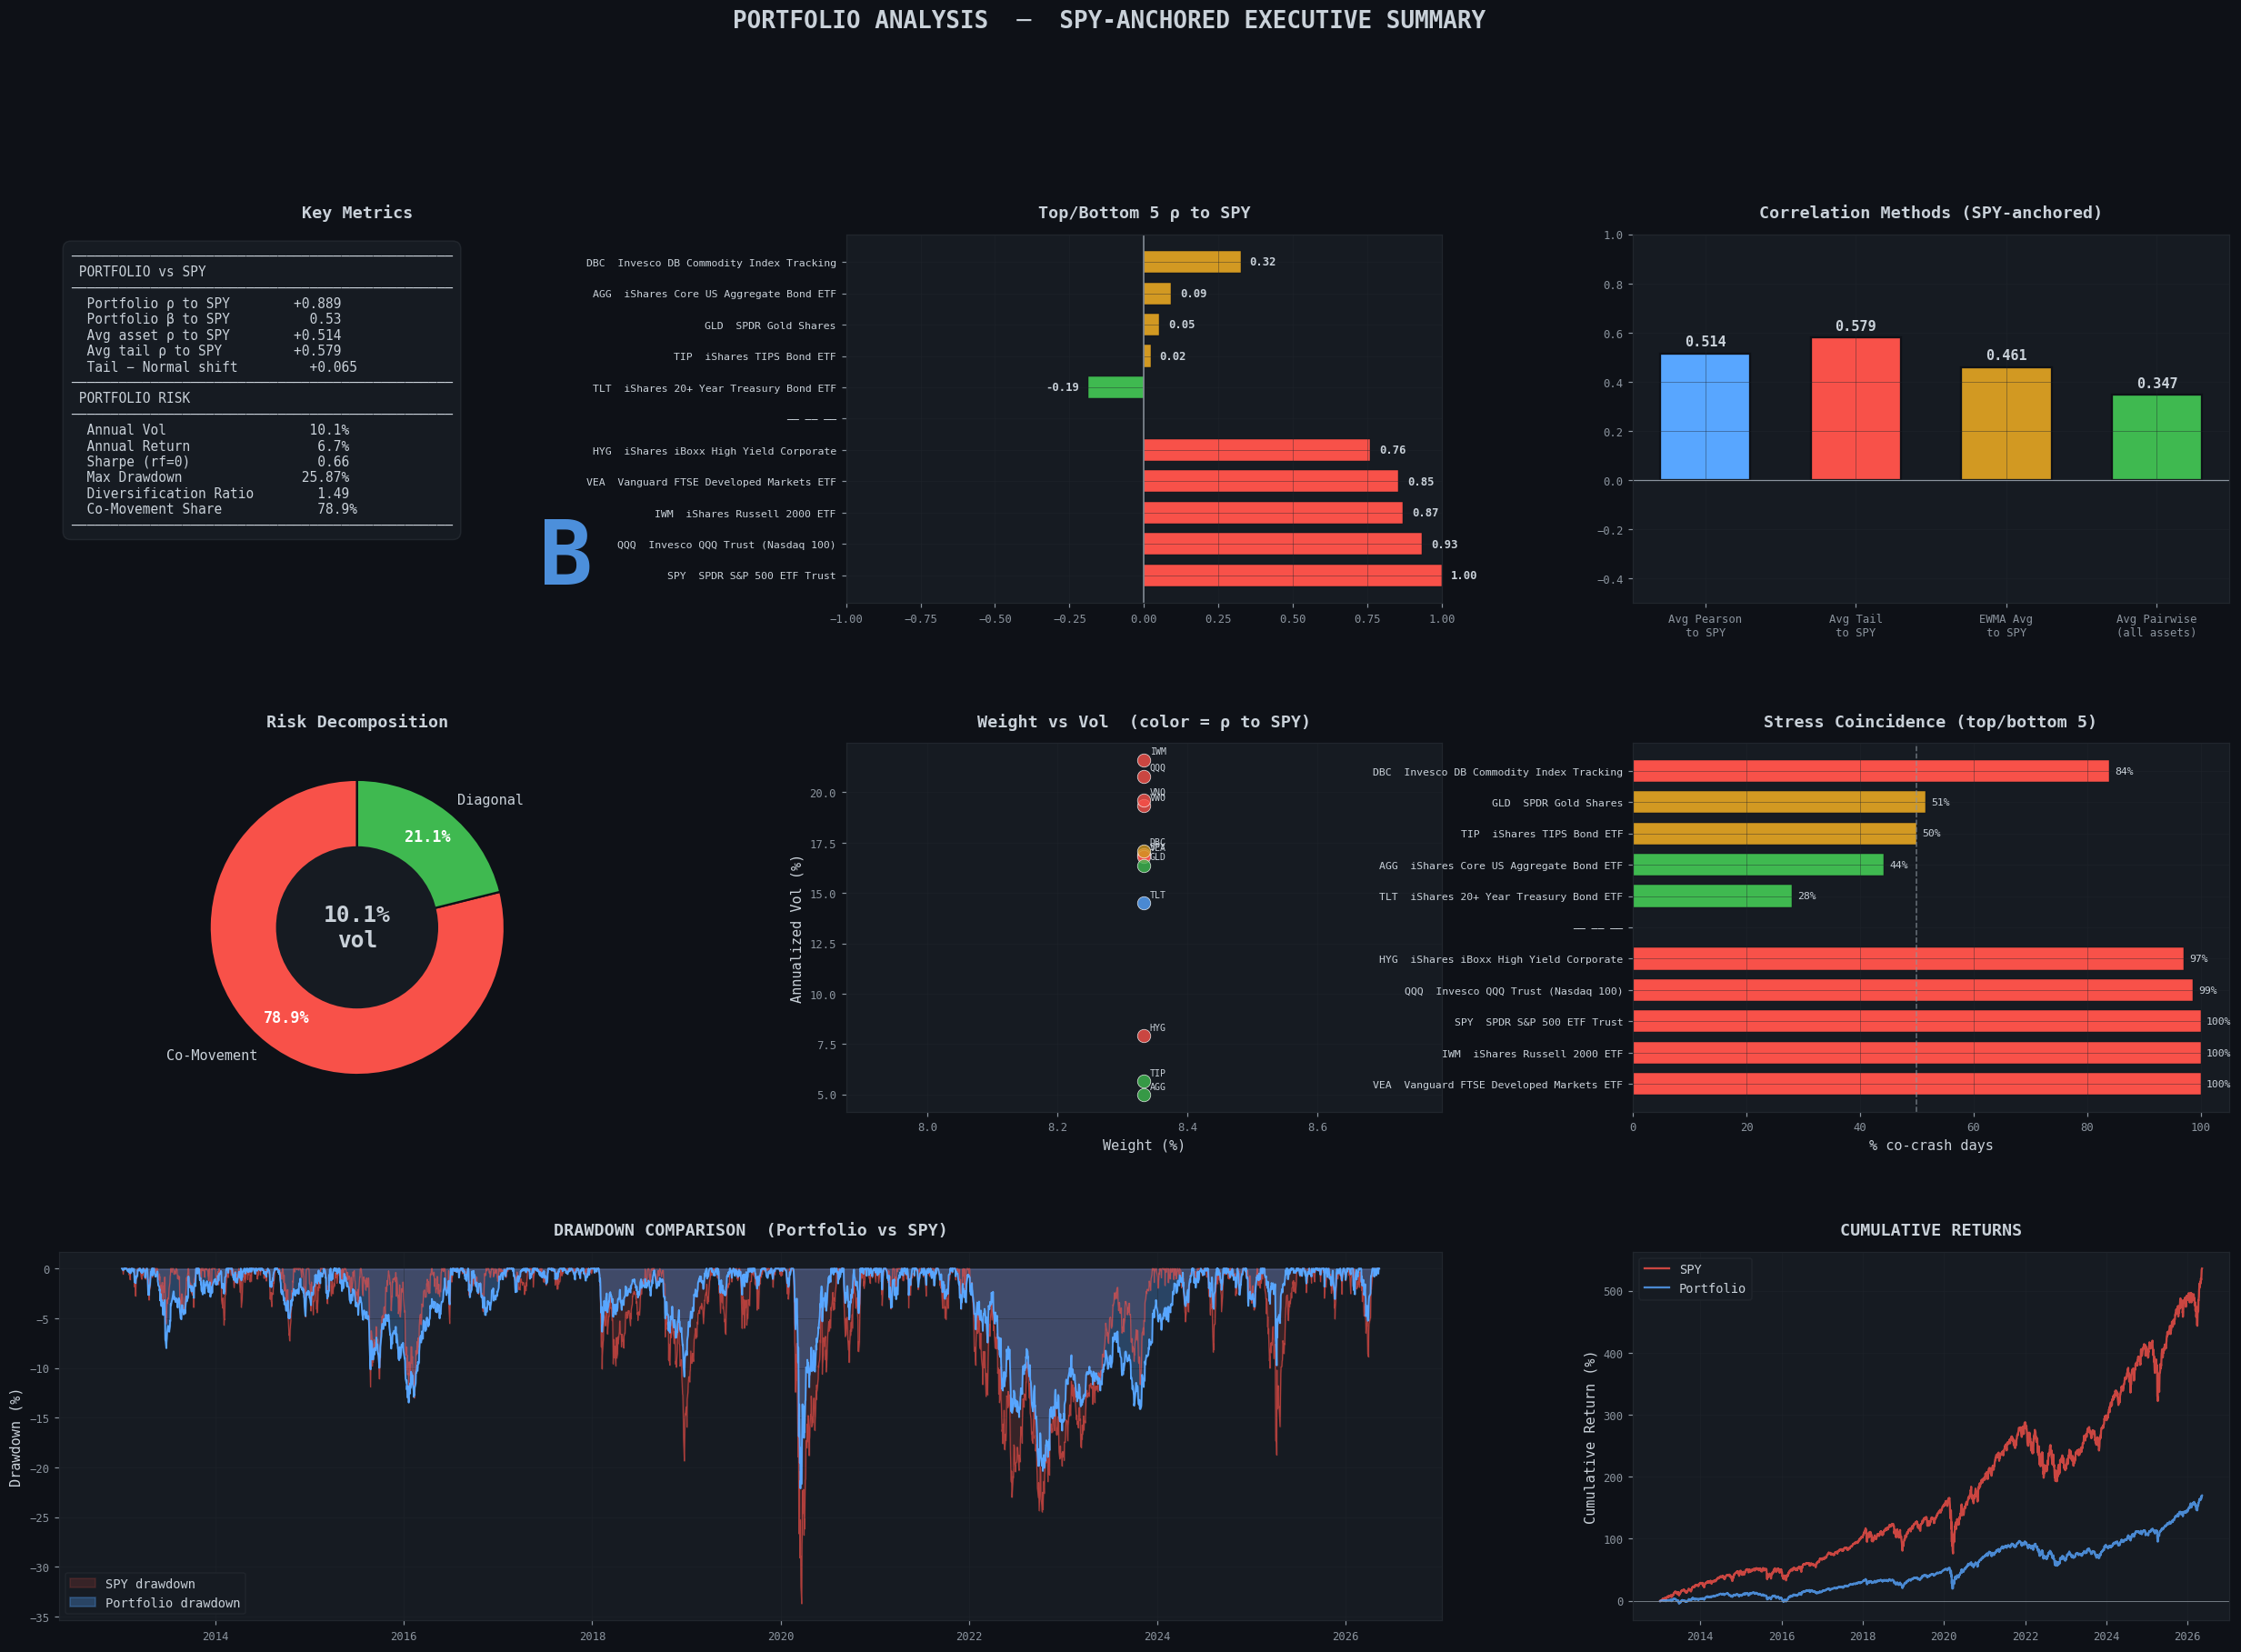

  ✓ 01 Executive dashboard (8-panel)


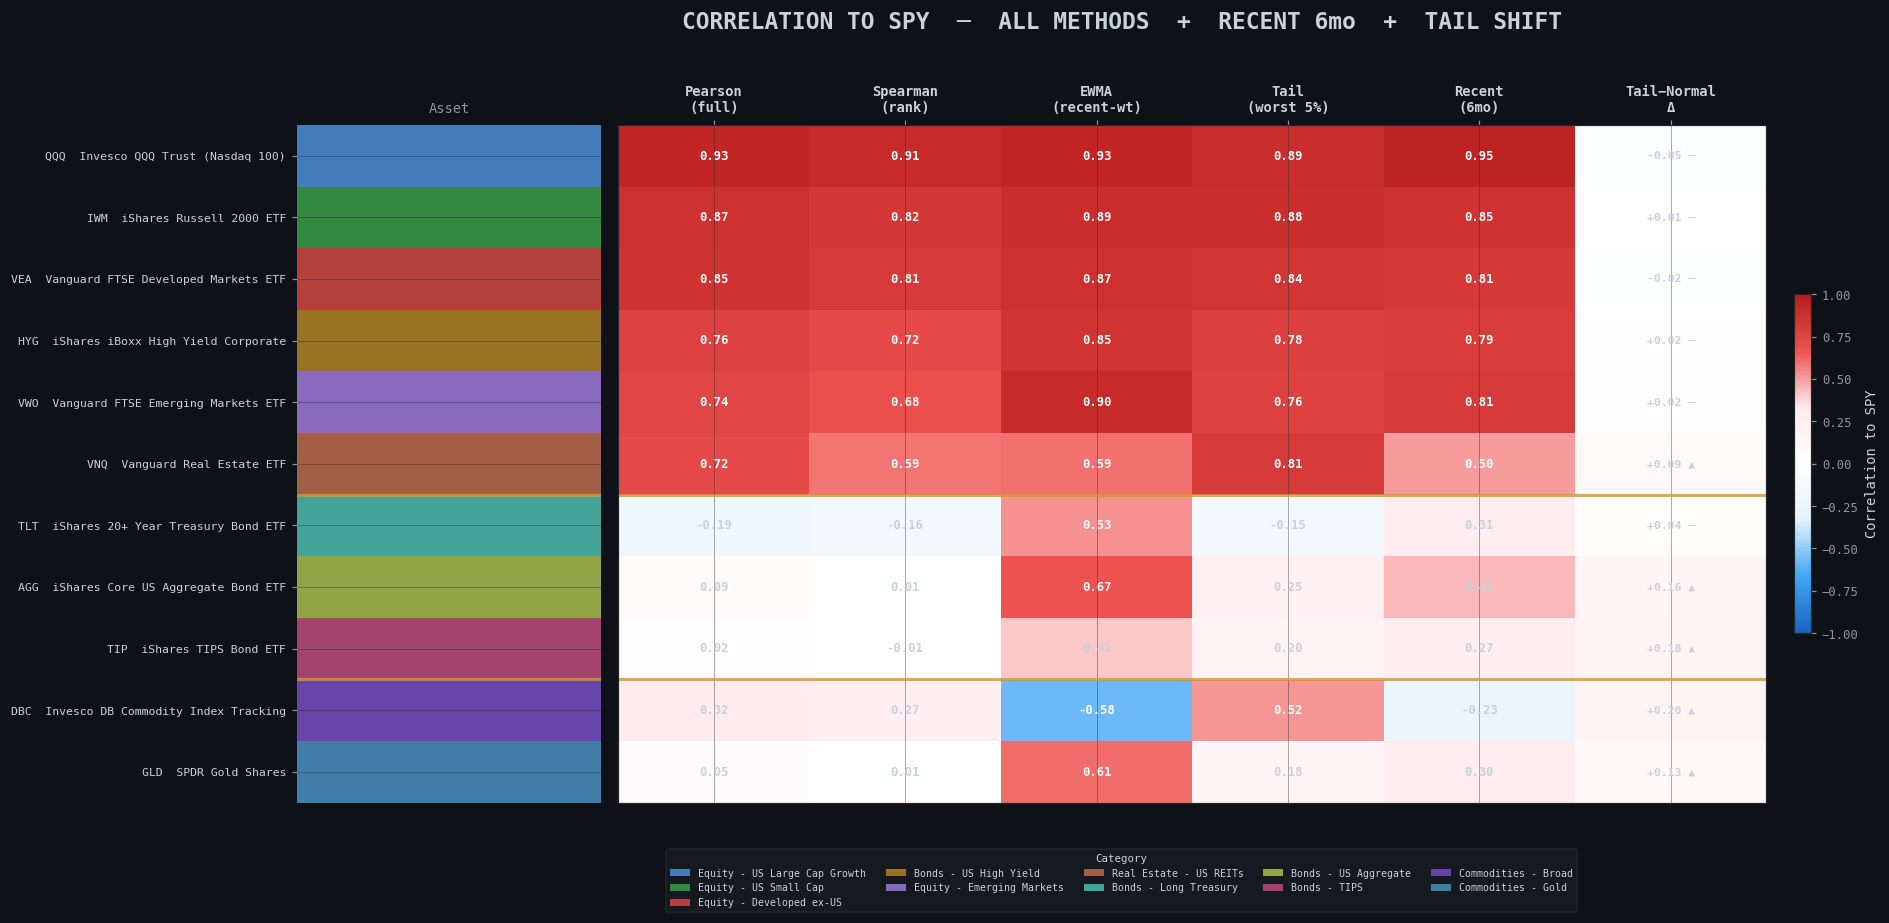

  ✓ 02 Correlation methods comparison


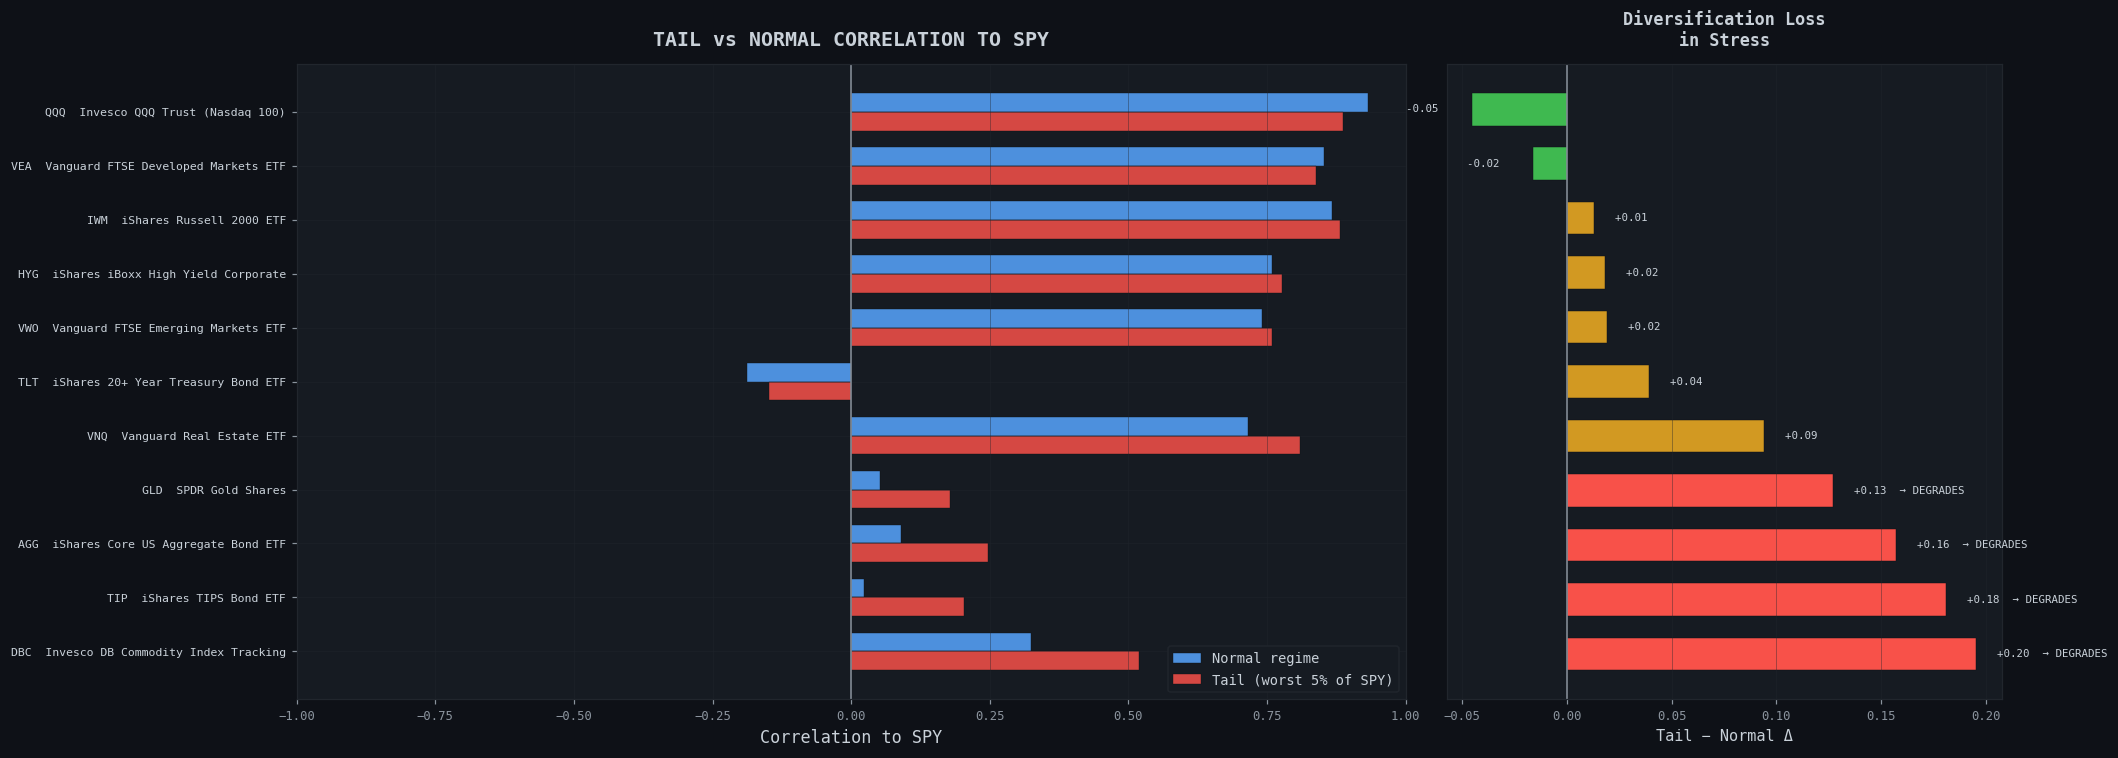

  ✓ 03 Tail-stress dashboard


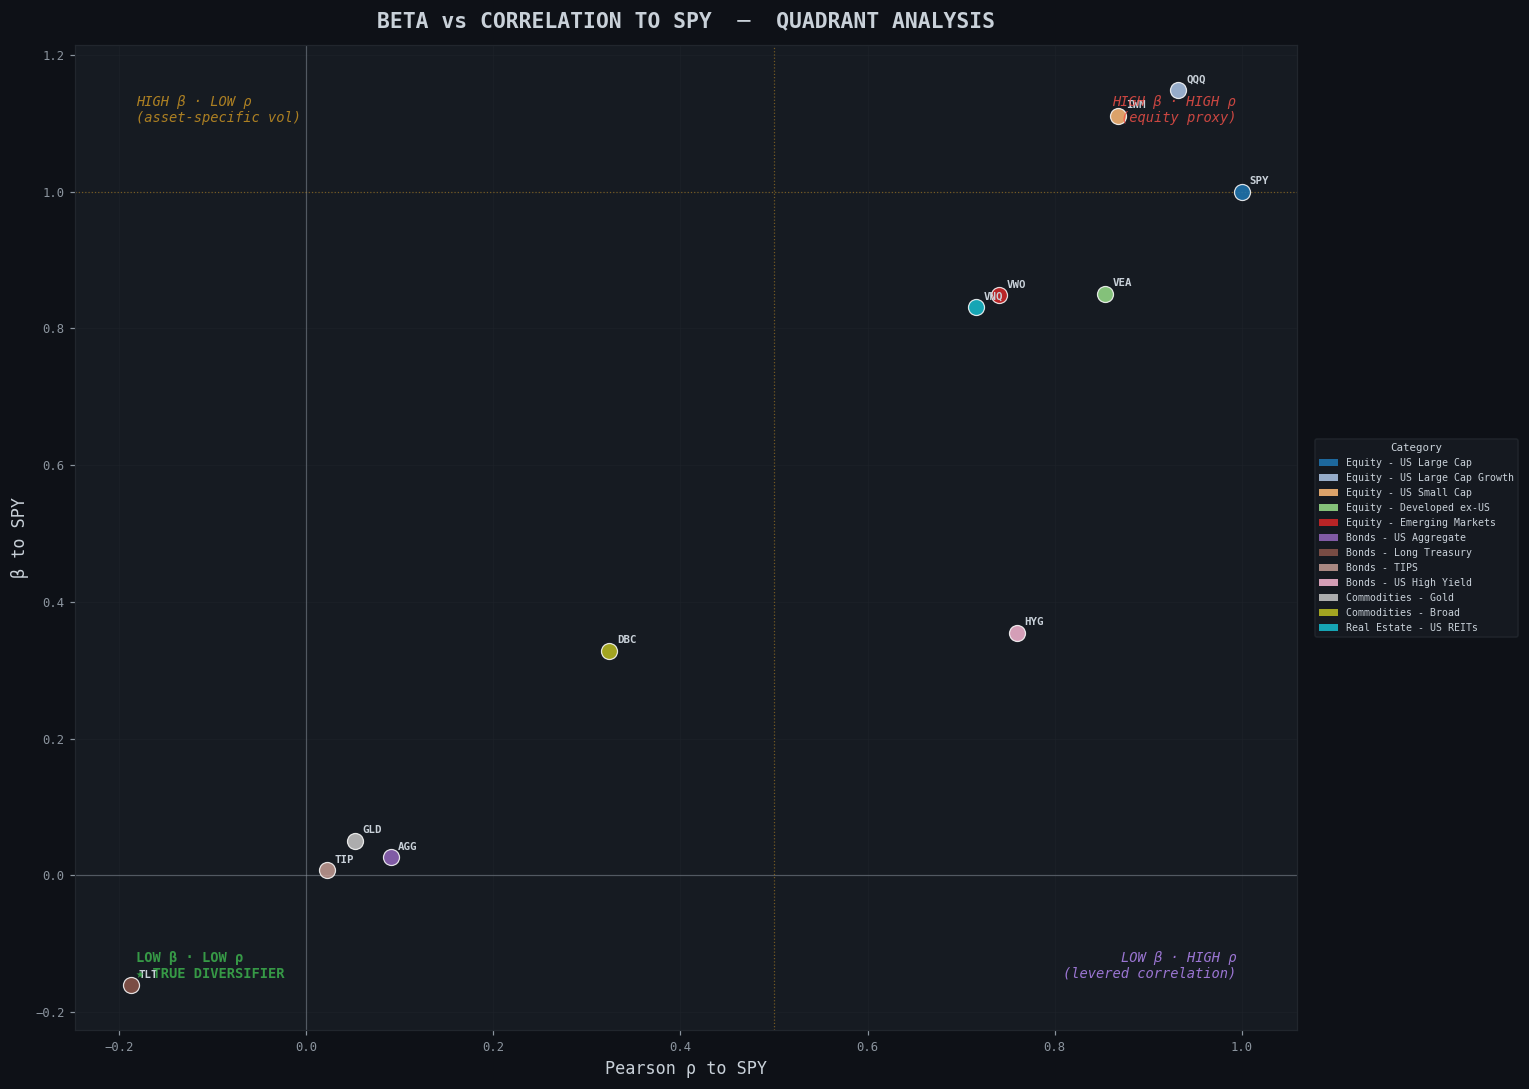

  ✓ 04 Beta vs correlation quadrant


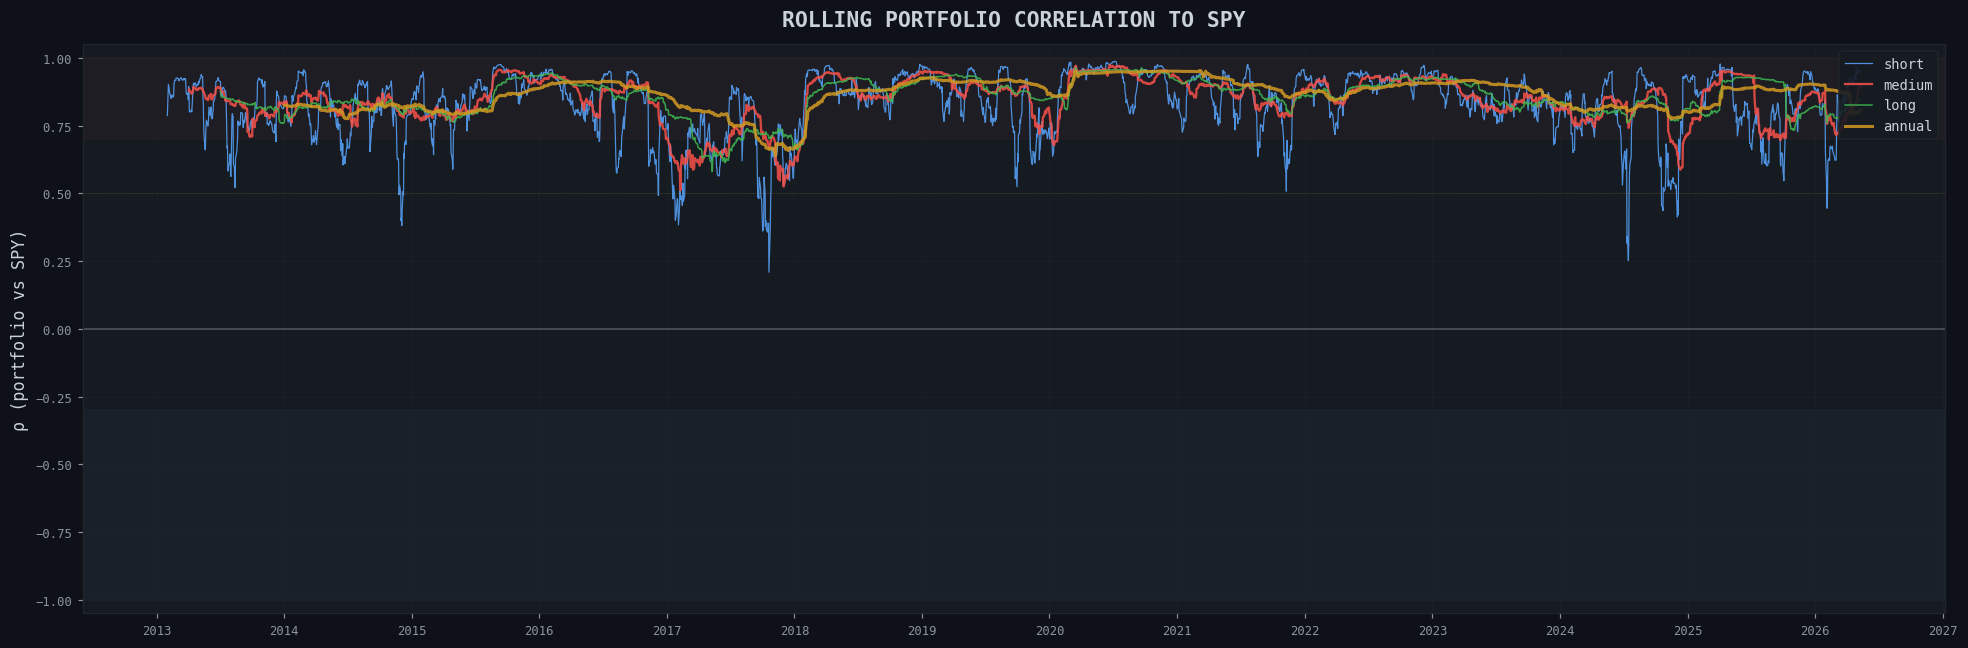

  ✓ 05 Rolling correlation panel


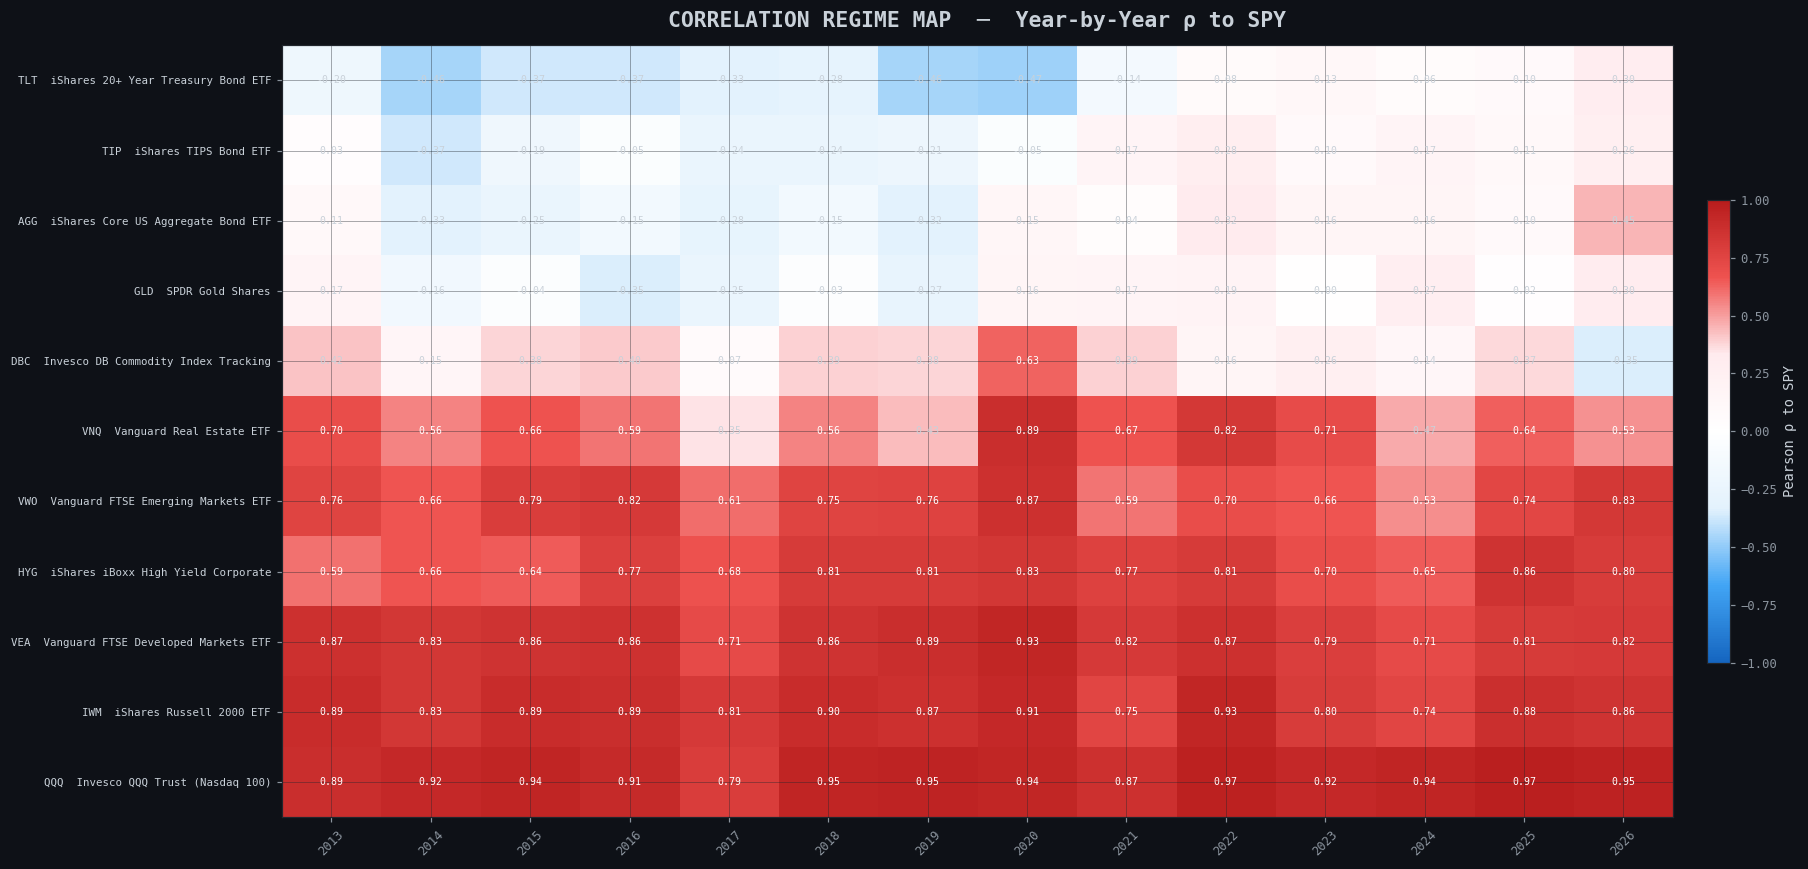

  ✓ 06 Correlation regime heatmap (yearly)


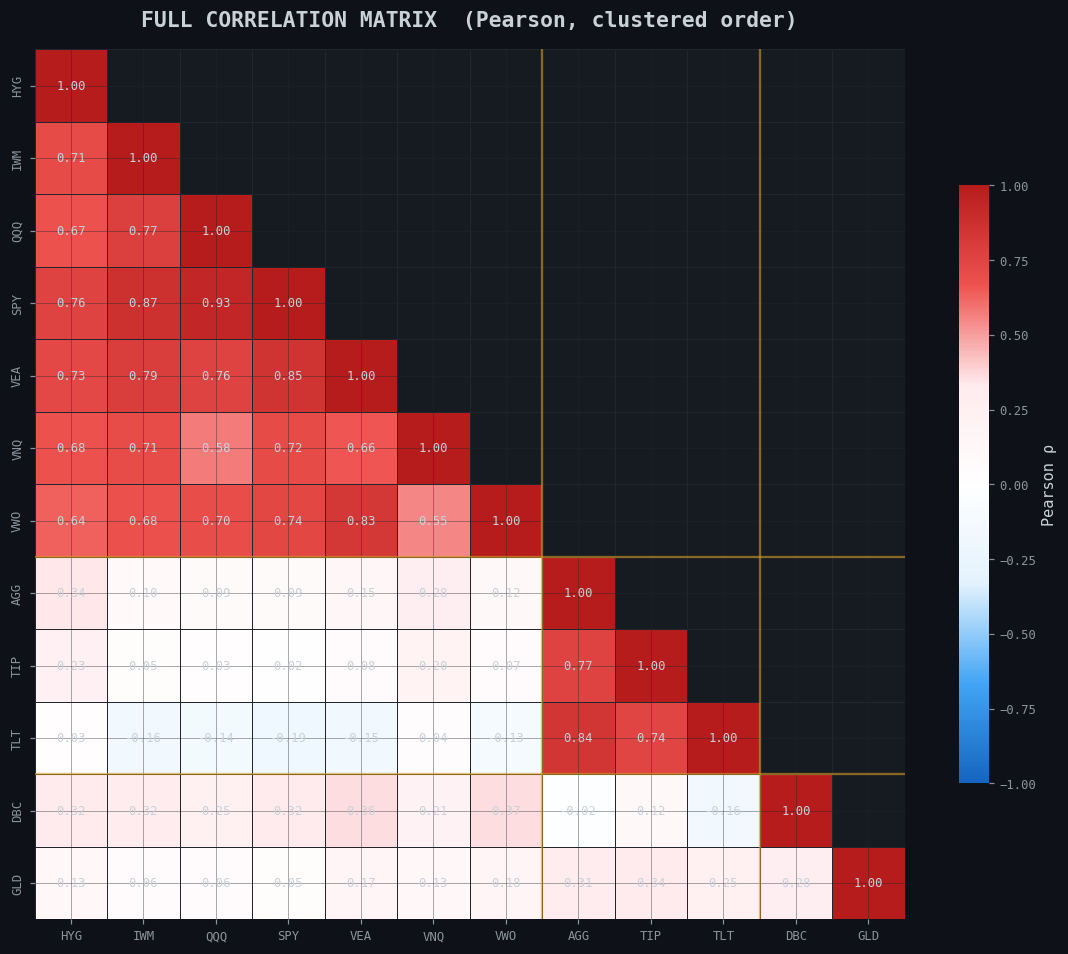

  ✓ 07 Full Pearson heatmap (clustered)


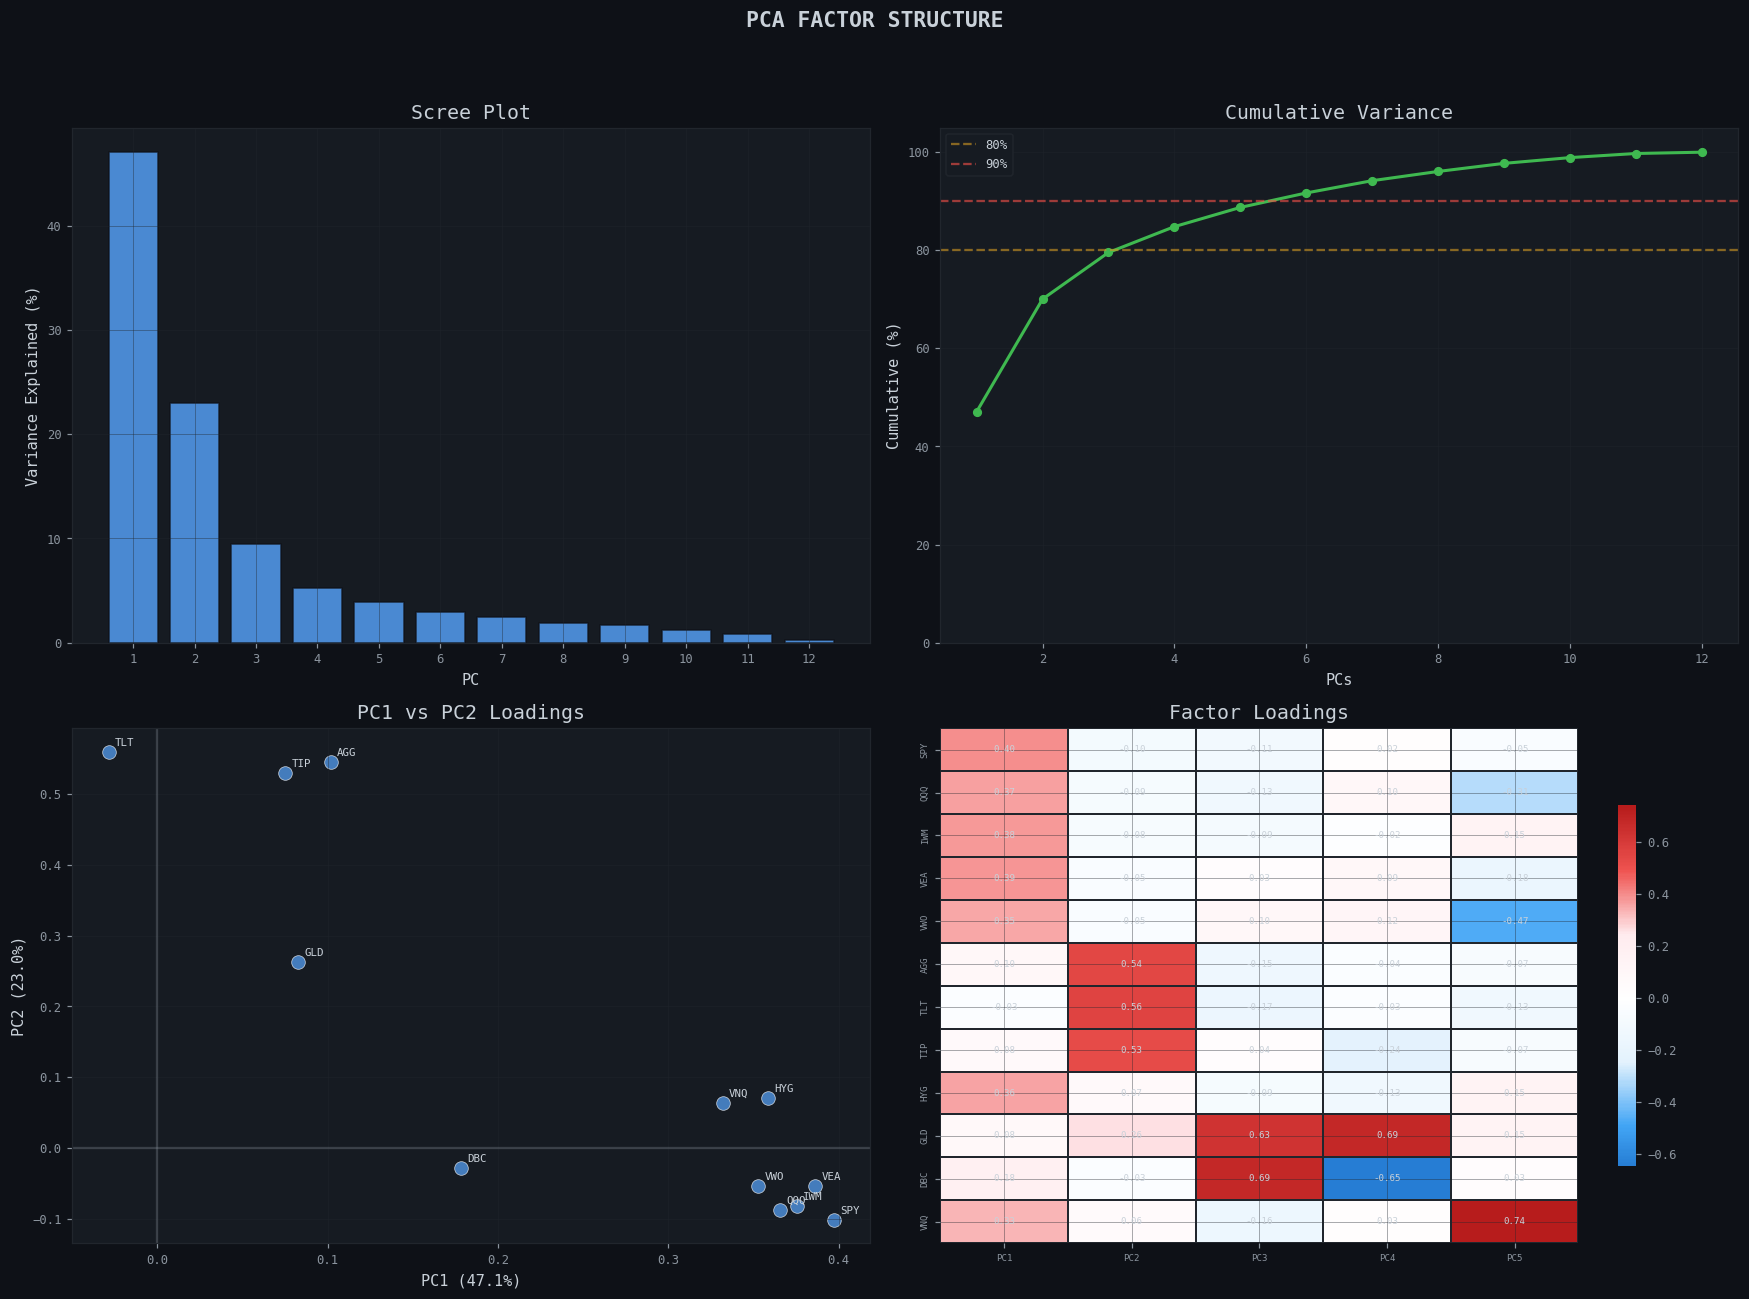

  ✓ 08 PCA factor structure


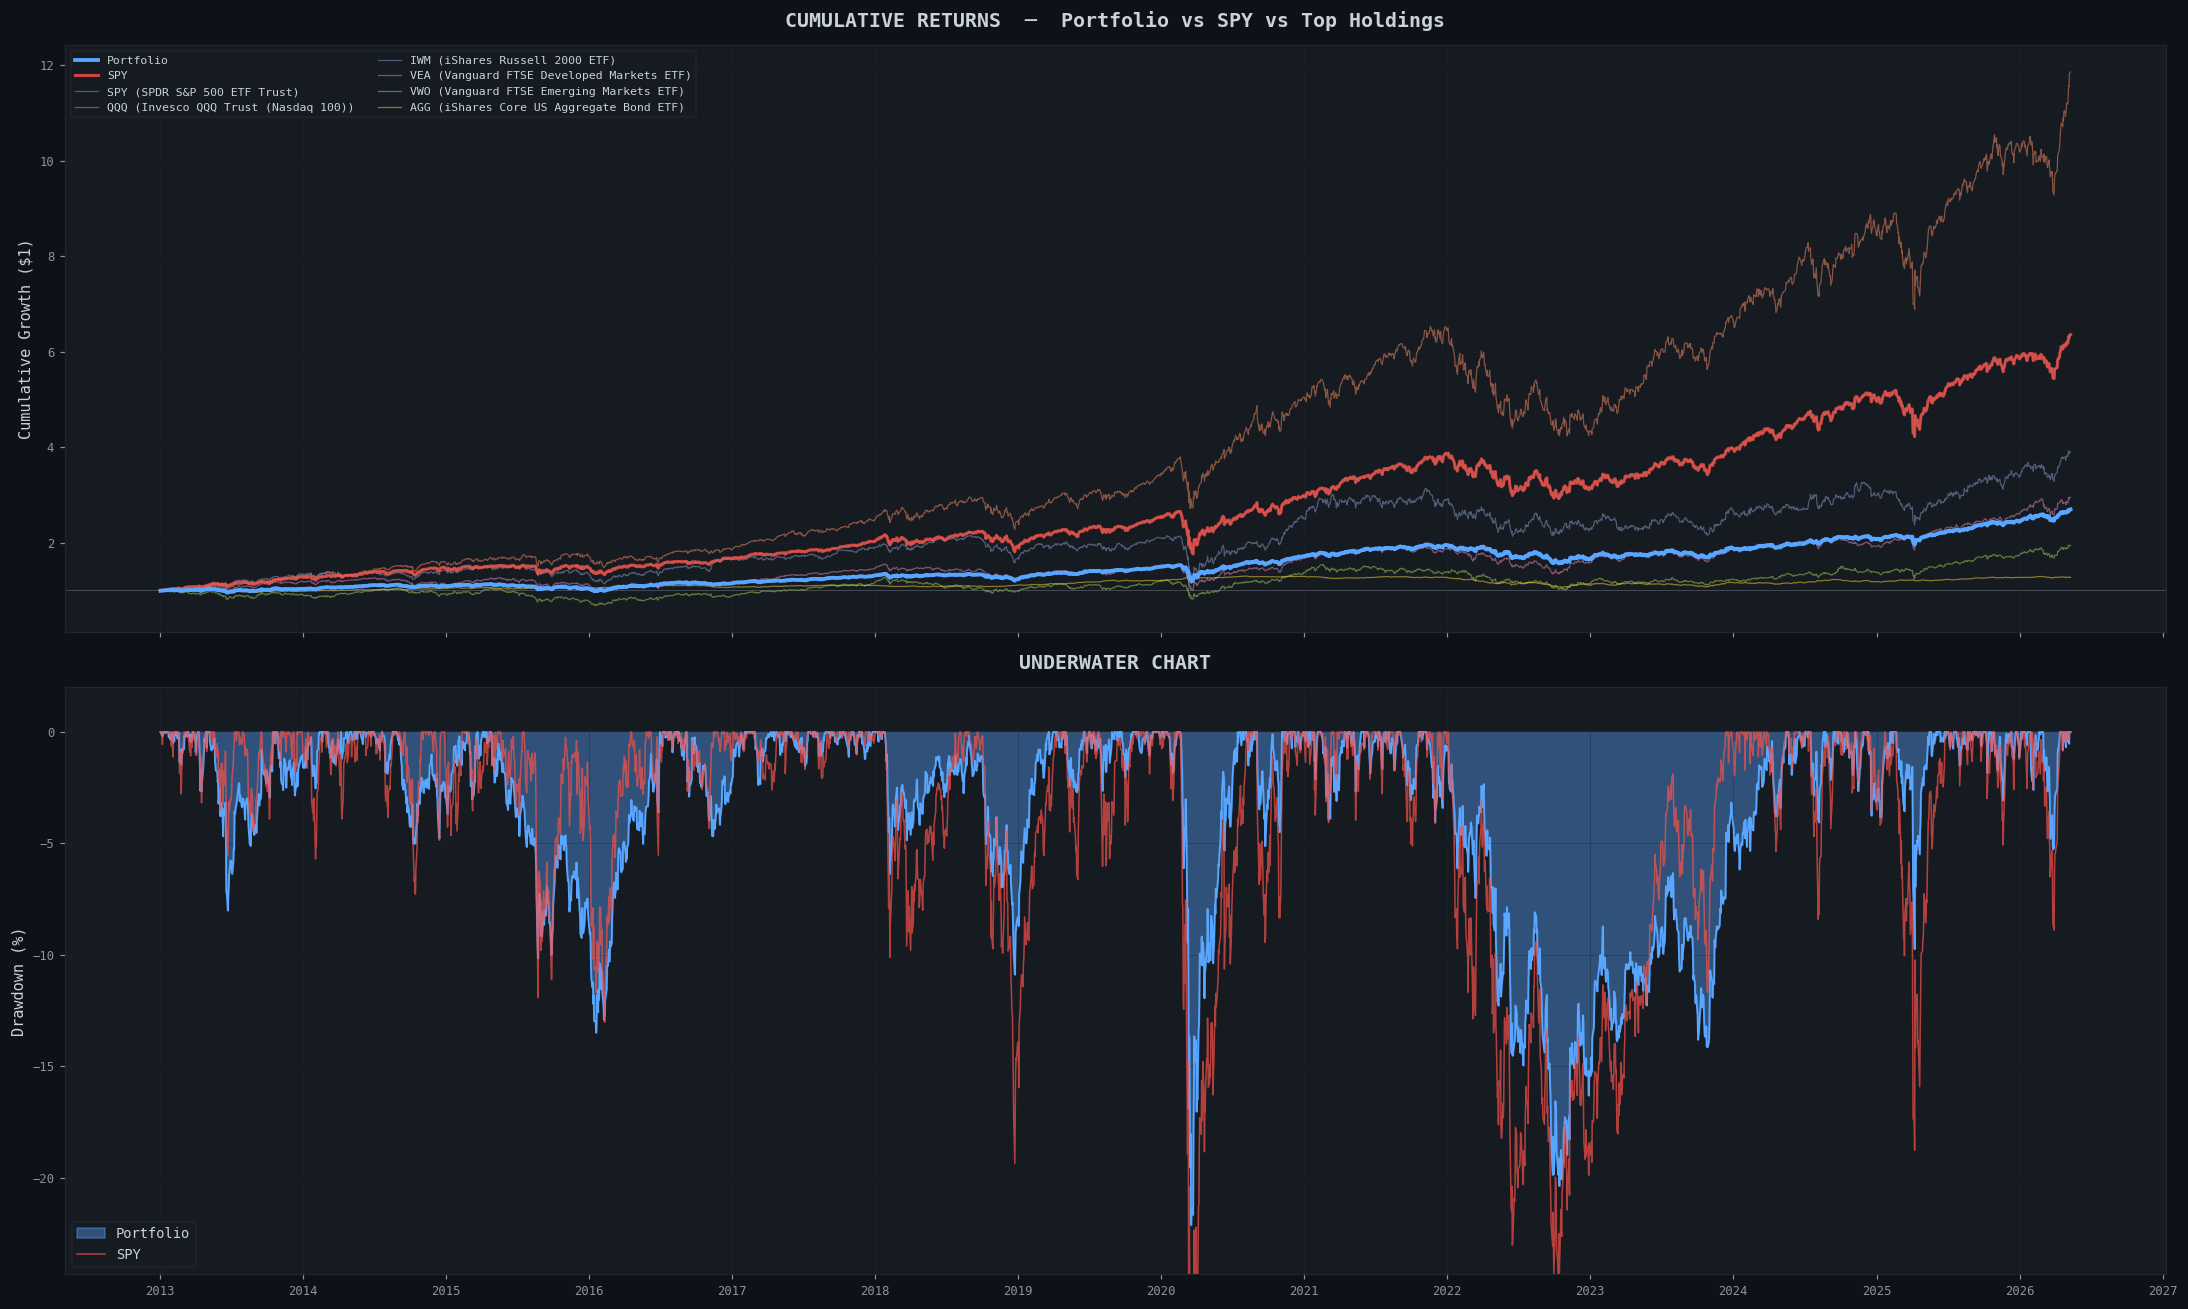

  ✓ 09 Drawdown & cumulative returns

════════════════════════════════════════════════════════════════════════════════
 ANALYSIS COMPLETE
════════════════════════════════════════════════════════════════════════════════


In [8]:
#  SECTION 12 — MAIN EXECUTION
# ══════════════════════════════════════════════════════════════════════════════

def run_full_analysis() -> Dict[str, Any]:
    print(_header("EXECUTING FULL PORTFOLIO ANALYSIS"))

    results: Dict[str, Any] = {}

    # ── 1. Fetch data ──
    all_tickers = list(set(TICKERS + [ANCHOR_ASSET]))
    prices, rets = fetch_prices_and_returns(all_tickers, START_DATE, END_DATE)
    if rets.empty:
        print("  ✗ No data returned. Aborting.")
        return {}

    # ── 2. Available portfolio assets ──
    avail = [t for t in TICKERS if t in rets.columns]
    if not avail:
        print("  ✗ None of the portfolio tickers have data. Aborting.")
        return {}
    port_rets = rets[avail].copy()

    # ── 3. Aligned weights ──
    weight_map = {p['ticker']: float(p['weight']) for p in PORTFOLIO}
    aligned_wts = np.array([weight_map.get(t, 0.0) for t in avail], dtype=float)
    s = float(aligned_wts.sum())
    if not np.isfinite(s) or s <= 0:
        print("  ⚠ Invalid weights — falling back to equal weight.")
        aligned_wts = np.ones(len(avail)) / len(avail)
    else:
        aligned_wts = aligned_wts / s

    anchor_returns = rets[ANCHOR_ASSET] if ANCHOR_ASSET in rets.columns else None

    # ── 4. Correlation suite ──
    corr_suite = calculate_correlation_suite(port_rets, aligned_wts, anchor_returns)
    results['corr_suite'] = corr_suite

    td = corr_suite.get('tail_diagnostics', {})
    print(f"\n  Tail diagnostics: mode={TAIL_MODE}, n_tail_days={td.get('n_tail_days')}, "
          f"pct={td.get('tail_pct_actual')}, threshold={td.get('threshold_return')}")
    if 'warning' in td:
        print(f"  ⚠ {td['warning']}")

    # ── 5. Rolling correlations ──
    rolling_corrs = None
    if anchor_returns is not None:
        sub_cols = avail if ANCHOR_ASSET in avail else avail + [ANCHOR_ASSET]
        sub_rets = rets[[c for c in sub_cols if c in rets.columns]].copy()
        rolling_corrs = calculate_rolling_correlations(sub_rets, ANCHOR_ASSET, ROLLING_WINDOWS)
        results['rolling_corrs'] = rolling_corrs

    # ── 6. Portfolio metrics ──
    pm = calculate_portfolio_metrics(port_rets, aligned_wts, corr_suite, anchor_returns)
    # Add EWMA avg corr for dashboard
    ewma_stats = _corr_stats(corr_suite['ewma'])
    pm['ewma_avg_corr'] = ewma_stats['mean']
    results['portfolio_metrics'] = pm

    # ── 7. Diversification structure ──
    pca_res   = run_pca_analysis(port_rets)
    enb_res   = calculate_effective_n_bets(corr_suite['pearson'])
    det_res   = calculate_correlation_determinant(corr_suite['pearson'])
    clust_res = run_clustering_analysis(corr_suite['pearson'], CLUSTER_DISTANCE_THRESHOLD)
    results.update({'pca': pca_res, 'enb': enb_res, 'det': det_res, 'clust': clust_res})

    # ── 8. Statistical tests ──
    stat_tests = run_statistical_tests(port_rets, corr_suite, aligned_wts)
    results['statistical_tests'] = stat_tests

    # ── 9. Validation ──
    warnings_list = validate_metrics(pm, corr_suite, det_res)
    results['warnings'] = warnings_list

    # ── 10. Highly correlated pairs ──
    high_pairs = find_highly_correlated_pairs(corr_suite['pearson'], threshold=0.80)
    results['high_corr_pairs'] = high_pairs

    # ══════════════════════════════════════════════════════════════════════
    #  REPORTING
    # ══════════════════════════════════════════════════════════════════════

    # Warnings
    if warnings_list:
        print(_header("⚠  VALIDATION WARNINGS"))
        for w in warnings_list:
            print(f"  • {w}")

    # Highly correlated pairs
    if high_pairs:
        print(_subheader("Highly Correlated Pairs (|ρ| ≥ 0.80)"))
        for pair in high_pairs[:12]:
            indicator = "⬆" if pair['correlation'] > 0 else "⬇"
            print(f"  {pair['asset_1']:<6} ↔ {pair['asset_2']:<6}   ρ = {pair['correlation']:+.3f}  {indicator}")

    # Console tables
    print_correlation_summary(corr_suite, pm)
    print_portfolio_metrics(pm)
    print_diversification_scorecard(pca_res, enb_res, det_res, clust_res, pm)
    print_statistical_tests(stat_tests)
    print_final_summary(pm, corr_suite)

    # Cluster composition
    print(_subheader("CLUSTER COMPOSITION"))
    for c_id in sorted(clust_res['cluster_map'].keys()):
        members = clust_res['cluster_map'][c_id]
        name_map = {p['ticker']: p['name'] for p in PORTFOLIO}
        print(f"\n  Cluster {c_id}  ({len(members)} assets):")
        for m in members:
            label = name_map.get(m, m)
            print(f"    {m:<6}  {label}")

    # ══════════════════════════════════════════════════════════════════════
    #  CHARTS  (consolidated 21 → 9, all SPY-anchored)
    # ══════════════════════════════════════════════════════════════════════

    print(_subheader("Generating Charts (9 visualizations, SPY-anchored)"))

    full_rets = rets  # includes SPY + portfolio tickers

    chart_calls = [
        ("01 Executive dashboard (8-panel)",
         lambda: plot_executive_dashboard(pm, full_rets, ANCHOR_ASSET, clust_res)),
        ("02 Correlation methods comparison",
         lambda: plot_spy_correlation_master(full_rets, ANCHOR_ASSET, clust_res)),
        ("03 Tail-stress dashboard",
         lambda: plot_tail_vs_normal_spy(full_rets, ANCHOR_ASSET)),
        ("04 Beta vs correlation quadrant",
         lambda: plot_beta_vs_correlation(pm)),
        ("05 Rolling correlation panel",
         lambda: plot_rolling_portfolio_spy(full_rets, avail, aligned_wts, ANCHOR_ASSET)),
        ("06 Correlation regime heatmap (yearly)",
         lambda: plot_correlation_regime_heatmap(full_rets, ANCHOR_ASSET)),
        ("07 Full Pearson heatmap (clustered)",
         lambda: plot_full_heatmap(corr_suite, clust_res)),
        ("08 PCA factor structure",
         lambda: plot_pca_results(pca_res, avail)),
        ("09 Drawdown & cumulative returns",
         lambda: plot_drawdown_analysis(full_rets, avail, aligned_wts, ANCHOR_ASSET)),
    ]

    for label, fn in chart_calls:
        try:
            fn()
            print(f"  ✓ {label}")
        except Exception as e:
            print(f"  ✗ {label} failed: {e}")

    print(_header("ANALYSIS COMPLETE"))
    return results


# ══════════════════════════════════════════════════════════════════════════════
#  EXECUTION
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    try:
        results = run_full_analysis()
    except Exception as e:
        print(f"\n{'═' * 80}")
        print(f" FATAL ERROR: {e}")
        print(f"{'═' * 80}")
        traceback.print_exc()
        sys.exit(1)